In [2]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()

# Get the parent directory path
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
print(f"Current directory: {current_dir}\nParent directory: {parent_dir}")
# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

Current directory: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations
Parent directory: /home/floodai/Desktop/Shivam


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from config import project_config
import importlib
importlib.reload(project_config) # In case the config has been modified. Since earlier no change was reflecting in the notebook. It was due to chaching of python modules.

<module 'config.project_config' from '/home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/config/project_config.py'>

### 1. Create realistic synthetic dataset

In [3]:
from src.data.dataset_creation import create_synthetic_dataset
# To run the generation with all the default settings, simply call the function.
create_synthetic_dataset()


--- Starting Dataset Generation ---
Generating 9 months of training data...
  - Generated 158,157,409 log entries.

Generating 1 month of validation data...
  - Generated 17,414,232 log entries.

Generating 2 month of test data...
  - Generated 35,107,580 log entries (after injecting anomalies).

Saving all datasets to CSV files...

✅ Dataset generation complete. All files saved in '/home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/data/raw'.


/tmp/ipykernel_1484029/3079234688.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  train_df.set_index('timestamp')['prompt_tokens'].resample('H').mean().plot(


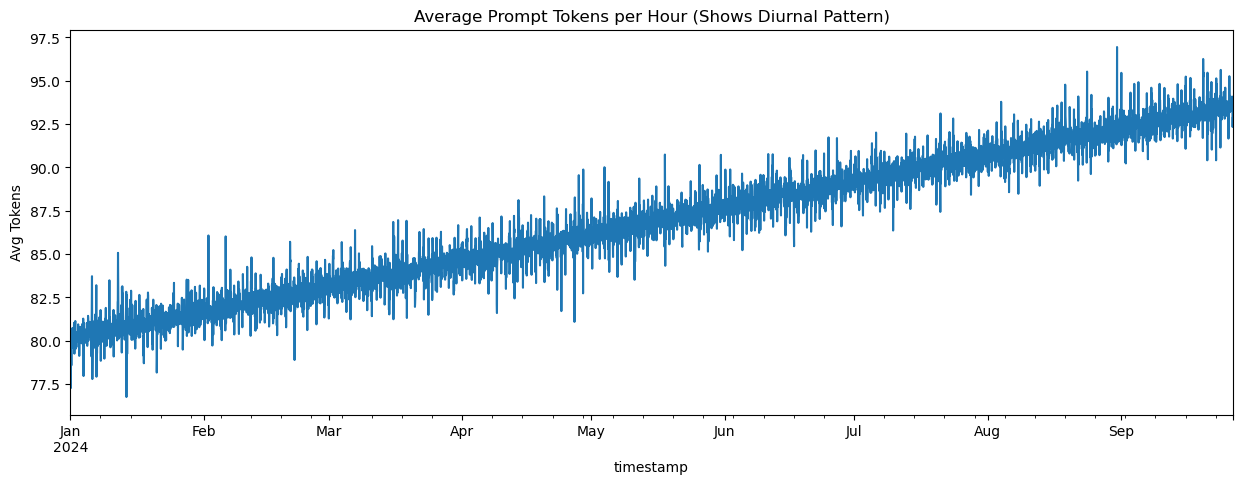

In [7]:
# Let's visualize the daily pattern in the new train data
train_df = pd.read_csv(
    os.path.join(project_config.RAW_DATA_DIR, 'llm_logs_train.csv'), 
    parse_dates=['timestamp']
)

# Now that the 'timestamp' column is a proper datetime type, this code will work perfectly.
train_df.set_index('timestamp')['prompt_tokens'].resample('H').mean().plot(
    figsize=(15, 5), 
    title='Average Prompt Tokens per Hour (Shows Diurnal Pattern)'
)

plt.ylabel('Avg Tokens')
plt.show()

/tmp/ipykernel_1484029/756282664.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  val_df.set_index('timestamp')['prompt_tokens'].resample('H').mean().plot(


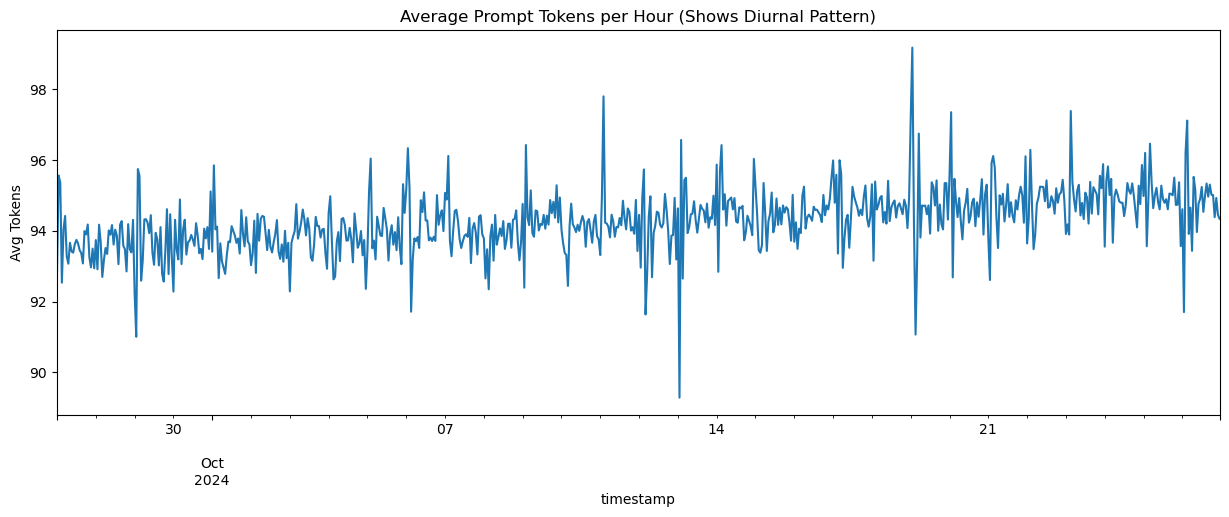

In [8]:
# Let's visualize the daily pattern in the new val data
val_df = pd.read_csv(
    os.path.join(project_config.RAW_DATA_DIR, 'llm_logs_val.csv'), 
    parse_dates=['timestamp']
)

# Now that the 'timestamp' column is a proper datetime type, this code will work perfectly.
val_df.set_index('timestamp')['prompt_tokens'].resample('H').mean().plot(
    figsize=(15, 5), 
    title='Average Prompt Tokens per Hour (Shows Diurnal Pattern)'
)

plt.ylabel('Avg Tokens')
plt.show()

/tmp/ipykernel_1484029/2962550595.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  test_df.set_index('timestamp')['prompt_tokens'].resample('H').mean().plot(


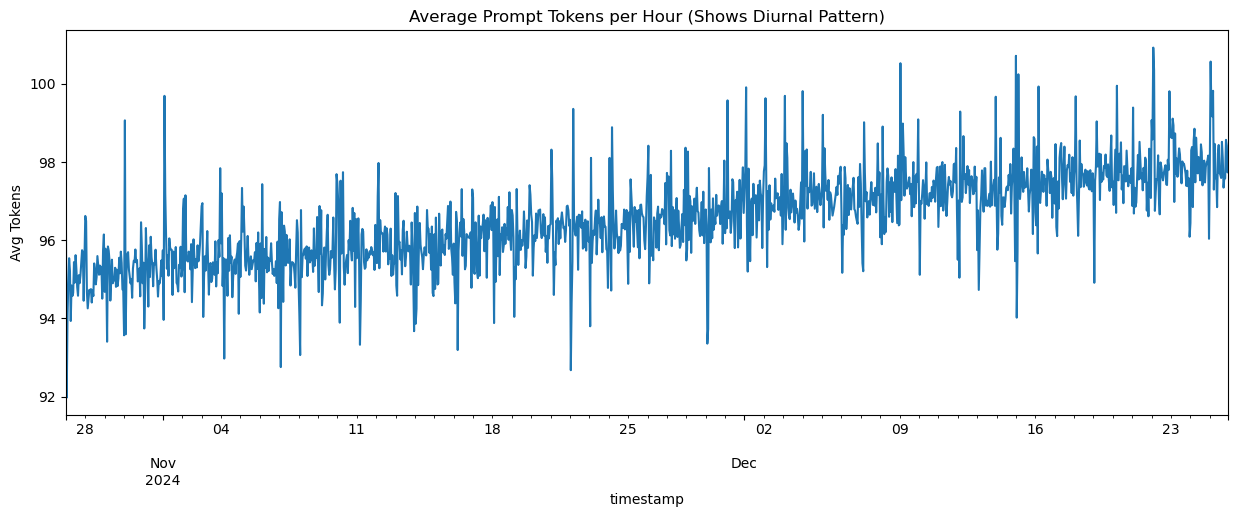

In [9]:
# Let's visualize the daily pattern in the new test data

test_df = pd.read_csv(
    os.path.join(project_config.RAW_DATA_DIR, 'llm_logs_test.csv'), 
    parse_dates=['timestamp']
)

# Now that the 'timestamp' column is a proper datetime type, this code will work perfectly.
test_df.set_index('timestamp')['prompt_tokens'].resample('H').mean().plot(
    figsize=(15, 5), 
    title='Average Prompt Tokens per Hour (Shows Diurnal Pattern)'
)

plt.ylabel('Avg Tokens')
plt.show()

### Phase 2: Feature Engineering & Data Preprocessing
Our goal is to convert the raw, event-based logs into a regular time series. We will do this by aggregating the data into fixed time windows and calculating a set of features that describe the system's state within each window.

In [ ]:
# Pringing the project configuration paths
print(f"{project_config.RAW_DATA_DIR}")
print(f"{project_config.PROCESSED_DATA_DIR}")
print(f"{project_config.PROJECT_NAME}")
print(f"{project_config.INTERIM_DATA_DIR}")

/home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/data/raw
/home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/data/processed
Anomaly-Detection-in-LLM-Operations
/home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/data/interim


In [31]:
from src.data.feature_engineering_and_preprocess_data import start_feature_engineering_and_data_preprocessing
start_feature_engineering_and_data_preprocessing()


Loading train, validation, test datasets...
Resampling data to 5min frequency...
Resampling data to 5min frequency...
Resampling data to 5min frequency...

--- Engineered Features (Training Set Head) ---
                     latency_ms_mean  latency_ms_std  latency_ms_max  \
timestamp                                                              
2024-01-01 00:00:00       250.408605       49.090610      386.139651   
2024-01-01 00:05:00       249.340122       50.679706      394.054573   
2024-01-01 00:10:00       250.015885       50.547768      415.536532   
2024-01-01 00:15:00       255.741090       52.393199      425.137114   
2024-01-01 00:20:00       250.145028       51.333862      400.272405   

                     prompt_tokens_mean  prompt_tokens_std  prompt_tokens_sum  \
timestamp                                                                       
2024-01-01 00:00:00           78.942214          72.438942       39234.280552   
2024-01-01 00:05:00           84.752184         

### Phase 3: Modeling

#### 3.1 Create dataloaders

In [ ]:
from src.data.make_dataset_class_and_create_dataloaders import create_dataloaders

# create dataloaders
# train_loader, val_loader, test_loader = create_dataloaders(load_data=False) 
# train_loader, val_loader, test_loader = create_dataloaders(load_data=True) # This will load the dataloaders if they exist.

Using device: cuda
Creating training and testing sequences...
Shape of training sequences: (77689, 72, 13)
Shape of validation sequences: (8569, 72, 13)
Shape of testing sequences: (17209, 72, 13)
Number of training batches: 304
Number of validation batches: 34
Number of testing batches: 68
DataLoaders saved to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/data/processed


In [6]:
from src.data.make_dataset_class_and_create_dataloaders import create_dataloaders
# Load the saved dataloaders
train_loader, val_loader, test_loader = create_dataloaders(load_data=True) # This will load the dataloaders if they exist.

Loading train, validation, test dataloaders...
Data loaded successfully!


#### 3.1 Model Training 

#### 3.1.1 Model initialization without regularization (resulted in overfitting)

In [7]:
import numpy as np
train_scaled = np.load(os.path.join(project_config.INTERIM_DATA_DIR, 'train_scaled.npy'))

In [ ]:
from src.models.model import LSTMAutoencoder_without_regularization # Importing the model without regularization


# # --- Model Instantiation --- Without regularization
# INPUT_DIM = train_scaled.shape[1] # Number of features
# LATENT_DIM = 32 # A hyperparameter to tune
# NUM_LAYERS = 2

# model = LSTMAutoencoder(INPUT_DIM, LATENT_DIM, NUM_LAYERS).to(device)
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # lr = 0.001

# print("\n--- Model Architecture ---")
# print(model)




#### 3.1.2 Model initialization with dropout regularization (to resolve overfitting problem)

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.models.model import LSTMAutoencoder_with_dropout_regularization # Importing the model with dropout regularization

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
INPUT_DIM = train_scaled.shape[1] # Number of features
LATENT_DIM = 32 # A hyperparameter to tune
NUM_LAYERS = 2
DROPOUT_PROB = 0.2 # Default dropout probability
model = LSTMAutoencoder_with_dropout_regularization(INPUT_DIM, LATENT_DIM, NUM_LAYERS, DROPOUT_PROB).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # lr = 0.001
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

print("\n--- Model Architecture ---")
print(model)

Using device: cuda

--- Model Architecture ---
LSTMAutoencoder_with_dropout_regularization(
  (encoder): LSTM(13, 32, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(32, 13, num_layers=2, batch_first=True, dropout=0.2)
)


#### 3.1.3 Starting training

In [40]:
import torch
import torch.optim as optim # A common alias
from src.visualization import plots
import importlib
importlib.reload(plots) # Reload the plots module to ensure any changes are reflected
import os
importlib.reload(project_config)

# --- NEW: Initialize the Learning Rate Scheduler ---
# This scheduler will reduce the LR if the validation loss plateaus.
# patience=5: Wait 5 epochs with no improvement before reducing LR.
# factor=0.1: Reduce LR by a factor of 10 (e.g., 0.001 -> 0.0001).
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

# Step 3: Writing and Executing the Training Loop
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, scheduler,
                train_val_loss_plots_dir, checkpoint_dir, early_stopping_patience=10):
    
    history = {'train_loss': [], 'val_loss': []}
    best_avg_val_loss = float('inf')
    
    # --- NEW: Early Stopping Initialization ---
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        # Using tqdm for a nice progress bar
        # from tqdm import tqdm
        # for seq_in, seq_out in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]"):
        for seq_in, seq_out in train_loader:
            seq_in, seq_out = seq_in.to(device), seq_out.to(device)

            # Forward pass
            outputs = model(seq_in)
            loss = criterion(outputs, seq_out)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # --- Validation ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for seq_in, seq_out in val_loader:
                seq_in, seq_out = seq_in.to(device), seq_out.to(device)
                outputs = model(seq_in)
                loss = criterion(outputs, seq_out)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        
        # --- NEW: Scheduler Step ---
        # The scheduler checks the validation loss to decide if it should reduce the learning rate.
        scheduler.step(avg_val_loss)

        print(f'Epoch [{epoch}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
        
        # --- Simplified and Robust Checkpointing ---
        if avg_val_loss < best_avg_val_loss:
            print(f"Validation loss improved ({best_avg_val_loss:.6f} --> {avg_val_loss:.6f}). Saving model...")
            best_avg_val_loss = avg_val_loss
            
            # --- NEW: Reset early stopping counter ---
            epochs_no_improve = 0
            
            # Save a complete checkpoint
            best_checkpoint_path = os.path.join(checkpoint_dir, 'best_model.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_avg_val_loss': best_avg_val_loss,
                'history': history
            }, best_checkpoint_path)

        else:
            # --- NEW: Increment early stopping counter ---
            epochs_no_improve += 1
            print(f"Validation loss did not improve. Early stopping counter: {epochs_no_improve}/{early_stopping_patience}")

        # Plotting logic remains the same
        if (epoch) % 4 == 0:
            train_val_loss_plot_path = os.path.join(train_val_loss_plots_dir, f'train_val_loss_epoch_{epoch}.png')
            plots.plot_train_val_loss(history, save_path=train_val_loss_plot_path)

        # --- NEW: Early Stopping Check ---
        if epochs_no_improve >= early_stopping_patience:
            print(f"\nEarly stopping triggered after {early_stopping_patience} epochs with no improvement.")
            break # Exit the training loop
            
    return history

# --- Start Training ---
NUM_EPOCHS = 500 # Set a high number, early stopping will find the optimal point
print("\n--- Starting Model Training with Scheduler and Early Stopping ---")

# Setup directories
checkpoint_dir = project_config.CHECKPOINT_DIR
train_val_loss_plots_dir = os.path.join(project_config.PLOTS_DIR, "train_val_loss_plots") 
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(train_val_loss_plots_dir, exist_ok=True)

# IMPORTANT: Use your clean 'val_loader', not the 'test_loader', for validation.
history = train_model(
    model, 
    train_loader, 
    val_loader,  # Use the correct validation set
    NUM_EPOCHS, 
    optimizer, 
    criterion, 
    scheduler,   # Pass the scheduler to the function
    train_val_loss_plots_dir, 
    checkpoint_dir,
    early_stopping_patience=10 # Stop if no improvement for 10 epochs
)


--- Starting Model Training with Scheduler and Early Stopping ---
Epoch [0/500], Train Loss: 0.678594, Val Loss: 0.695928
Validation loss improved (inf --> 0.695928). Saving model...
Saved training loss plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/plots/train_val_loss_plots/train_val_loss_epoch_0.png
Epoch [1/500], Train Loss: 0.551189, Val Loss: 0.645904
Validation loss improved (0.695928 --> 0.645904). Saving model...
Epoch [2/500], Train Loss: 0.531842, Val Loss: 0.617609
Validation loss improved (0.645904 --> 0.617609). Saving model...
Epoch [3/500], Train Loss: 0.519981, Val Loss: 0.626266
Validation loss did not improve. Early stopping counter: 1/10
Epoch [4/500], Train Loss: 0.509826, Val Loss: 0.604870
Validation loss improved (0.617609 --> 0.604870). Saving model...
Saved training loss plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/plots/train_val_loss_plots/train_val_loss_epoch_4.png
Epoch [5/500], Train

## Training again with 3 layers instead of 2. There could be risk of overfitting. Lets verify it.

In [33]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.models.model import LSTMAutoencoder_with_dropout_regularization # Importing the model with dropout regularization

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
INPUT_DIM = train_scaled.shape[1] # Number of features
LATENT_DIM = 32 # A hyperparameter to tune
NUM_LAYERS = 3
# We now explicitly pass the desired dropout probability to the model's constructor.
DROPOUT_PROB = 0.3 # Define the dropout rate as a variable for clarity

model = LSTMAutoencoder_with_dropout_regularization(
    INPUT_DIM, 
    LATENT_DIM, 
    NUM_LAYERS,
    dropout_prob=DROPOUT_PROB # Pass the argument here
).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) # lr = 0.001
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5)

print("\n--- Model Architecture ---")
print(model)

Using device: cuda

--- Model Architecture ---
LSTMAutoencoder_with_dropout_regularization(
  (encoder): LSTM(13, 32, num_layers=3, batch_first=True, dropout=0.3)
  (decoder): LSTM(32, 13, num_layers=3, batch_first=True, dropout=0.3)
)


In [34]:
import torch
import torch.optim as optim # A common alias
from src.visualization import plots
import importlib
importlib.reload(plots) # Reload the plots module to ensure any changes are reflected
import os
importlib.reload(project_config)

# --- NEW: Initialize the Learning Rate Scheduler ---
# This scheduler will reduce the LR if the validation loss plateaus.
# patience=5: Wait 5 epochs with no improvement before reducing LR.
# factor=0.1: Reduce LR by a factor of 10 (e.g., 0.001 -> 0.0001).
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=5, verbose=True)

# Step 3: Writing and Executing the Training Loop
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion, scheduler,
                train_val_loss_plots_dir, checkpoint_dir, early_stopping_patience=10):
    
    history = {'train_loss': [], 'val_loss': []}
    best_avg_val_loss = float('inf')
    
    # --- NEW: Early Stopping Initialization ---
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.train()
        total_train_loss = 0
        # Using tqdm for a nice progress bar
        # from tqdm import tqdm
        # for seq_in, seq_out in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]"):
        for seq_in, seq_out in train_loader:
            seq_in, seq_out = seq_in.to(device), seq_out.to(device)

            # Forward pass
            outputs = model(seq_in)
            loss = criterion(outputs, seq_out)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        history['train_loss'].append(avg_train_loss)

        # --- Validation ---
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for seq_in, seq_out in val_loader:
                seq_in, seq_out = seq_in.to(device), seq_out.to(device)
                outputs = model(seq_in)
                loss = criterion(outputs, seq_out)
                total_val_loss += loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        history['val_loss'].append(avg_val_loss)
        
        # --- NEW: Scheduler Step ---
        # The scheduler checks the validation loss to decide if it should reduce the learning rate.
        scheduler.step(avg_val_loss)

        print(f'Epoch [{epoch}/{num_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')
        
        # --- Simplified and Robust Checkpointing ---
        if avg_val_loss < best_avg_val_loss:
            print(f"Validation loss improved ({best_avg_val_loss:.6f} --> {avg_val_loss:.6f}). Saving model...")
            best_avg_val_loss = avg_val_loss
            
            # --- NEW: Reset early stopping counter ---
            epochs_no_improve = 0
            
            # Save a complete checkpoint
            best_checkpoint_path = os.path.join(checkpoint_dir, 'best_model.pth')
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_avg_val_loss': best_avg_val_loss,
                'history': history
            }, best_checkpoint_path)

        else:
            # --- NEW: Increment early stopping counter ---
            epochs_no_improve += 1
            print(f"Validation loss did not improve. Early stopping counter: {epochs_no_improve}/{early_stopping_patience}")

        # Plotting logic remains the same
        if (epoch) % 4 == 0:
            train_val_loss_plot_path = os.path.join(train_val_loss_plots_dir, f'train_val_loss_epoch_{epoch}.png')
            plots.plot_train_val_loss(history, save_path=train_val_loss_plot_path)

        # --- NEW: Early Stopping Check ---
        if epochs_no_improve >= early_stopping_patience:
            print(f"\nEarly stopping triggered after {early_stopping_patience} epochs with no improvement.")
            break # Exit the training loop
            
    return history

# --- Start Training ---
NUM_EPOCHS = 500 # Set a high number, early stopping will find the optimal point
print("\n--- Starting Model Training with Scheduler and Early Stopping ---")

# Setup directories
checkpoint_dir = project_config.CHECKPOINT_DIR
train_val_loss_plots_dir = os.path.join(project_config.PLOTS_DIR, "train_val_loss_plots") 
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(train_val_loss_plots_dir, exist_ok=True)

# IMPORTANT: Use your clean 'val_loader', not the 'test_loader', for validation.
history = train_model(
    model, 
    train_loader, 
    val_loader,  # Use the correct validation set
    NUM_EPOCHS, 
    optimizer, 
    criterion, 
    scheduler,   # Pass the scheduler to the function
    train_val_loss_plots_dir, 
    checkpoint_dir,
    early_stopping_patience=10 # Stop if no improvement for 10 epochs
)


--- Starting Model Training with Scheduler and Early Stopping ---
Epoch [0/500], Train Loss: 0.752863, Val Loss: 1.077787
Validation loss improved (inf --> 1.077787). Saving model...
Saved training loss plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/plots/train_val_loss_plots/train_val_loss_epoch_0.png
Epoch [1/500], Train Loss: 0.660927, Val Loss: 1.066246
Validation loss improved (1.077787 --> 1.066246). Saving model...
Epoch [2/500], Train Loss: 0.617090, Val Loss: 0.862691
Validation loss improved (1.066246 --> 0.862691). Saving model...
Epoch [3/500], Train Loss: 0.575875, Val Loss: 0.712163
Validation loss improved (0.862691 --> 0.712163). Saving model...
Epoch [4/500], Train Loss: 0.541083, Val Loss: 0.670594
Validation loss improved (0.712163 --> 0.670594). Saving model...
Saved training loss plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/plots/train_val_loss_plots/train_val_loss_epoch_4.png
Epoch [5/500], T

### Phase 4: Anomaly Detection and Evaluation


In [ ]:
# Step 1: Get Reconstruction Errors for the Entire Test Set

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
import os
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the best model checkpoint
from src.models.model import LSTMAutoencoder_with_dropout_regularization # Importing the model with dropout regularization

checkpoint_path = os.path.join(project_config.CHECKPOINT_DIR, 'best_model.pth')
INPUT_DIM = train_scaled.shape[1] # Number of features
LATENT_DIM = 32 # A hyperparameter to tune
NUM_LAYERS = 2
model = LSTMAutoencoder_with_dropout_regularization(INPUT_DIM, LATENT_DIM, NUM_LAYERS).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()  # Set the model to evaluation mode

LSTMAutoencoder_with_dropout_regularization(
  (encoder): LSTM(13, 32, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(32, 13, num_layers=2, batch_first=True, dropout=0.2)
)

In [11]:
# --- Function to get reconstruction errors ---
def get_reconstruction_errors(model, loader):
    """
    Calculates reconstruction errors for a given dataloader.

    Returns both the overall error for each sequence and the detailed 
    error for each feature within each sequence.

    Args:
        model (nn.Module): The trained autoencoder model.
        loader (DataLoader): The DataLoader to evaluate.

    Returns:
        tuple[np.array, np.array]: 
            - A 1D array of the average reconstruction error for each sequence.
            - A 2D array of the average reconstruction error for each feature in each sequence.
    """
    all_errors = []
    all_feature_errors = []
    criterion = nn.MSELoss(reduction='none') # Get per-element losses

    with torch.no_grad():
        for seq_in, _ in loader:
            seq_in = seq_in.to(device)
            reconstructed = model(seq_in)
            
            # loss shape: (batch_size, sequence_length, num_features)
            loss = criterion(reconstructed, seq_in)
            
            # --- Overall Error ---
            # Average over all dimensions (timesteps and features) for a single error value per sequence.
            # Shape becomes: (batch_size,)
            error_per_sequence = torch.mean(loss, dim=(1, 2))
            all_errors.extend(error_per_sequence.cpu().numpy())
            
            # --- Per-Feature Error ---
            # Average ONLY over the time dimension (dim=1) to keep the feature dimension.
            # Shape becomes: (batch_size, num_features)
            feature_error_per_sequence = torch.mean(loss, dim=1)
            all_feature_errors.extend(feature_error_per_sequence.cpu().numpy())
            
    return np.array(all_errors), np.array(all_feature_errors)

# # Calculate errors on the NORMAL training data
# print("Calculating reconstruction errors on the training set...")
# train_reconstruction_errors, train_featue_errors  = get_reconstruction_errors(model, train_loader)
# # print(f"Calculated {len(train_reconstruction_errors)} number of training reconstruction errors.")

# # Calculate errors on the TEST data (with anomalies)
# print("Calculating reconstruction errors on the test set...")
# test_reconstruction_errors, test_feature_errors = get_reconstruction_errors(model, test_loader)
# # print(f"Calculated {len(test_reconstruction_errors)} number of test reconstruction errors.")

#### Reconstruction error with 3 layers

In [ ]:
# Calculate errors on the NORMAL training data
print("Calculating reconstruction errors on the training set...")
train_reconstruction_errors, train_featue_errors  = get_reconstruction_errors(model, train_loader)
# print(f"Calculated {len(train_reconstruction_errors)} number of training reconstruction errors.")

# Calculate errors on the TEST data (with anomalies)
print("Calculating reconstruction errors on the test set...")
test_reconstruction_errors, test_feature_errors = get_reconstruction_errors(model, test_loader)
# print(f"Calculated {len(test_reconstruction_errors)} number of test reconstruction errors.")

print(f"Train reconstruction error statistics: Min={np.min(train_reconstruction_errors):.4f}, Mean={np.mean(train_reconstruction_errors):.4f}, Max={np.max(train_reconstruction_errors):.4f}, Std={np.std(train_reconstruction_errors):.4f}")
print(f"Test reconstrucntion error statistics: Min={np.min(test_reconstruction_errors):.4f}, Mean={np.mean(test_reconstruction_errors):.4f}, Max={np.max(test_reconstruction_errors):.4f}, Std={np.std(test_reconstruction_errors):.4f}")


Calculating reconstruction errors on the training set...
Calculating reconstruction errors on the test set...
Train reconstruction error statistics: Min=0.1366, Mean=0.4650, Max=2.0984, Std=0.3683
Test reconstrucntion error statistics: Min=0.2991, Mean=7.0483, Max=1496.0151, Std=85.0321


#### Reconstruction error with 2 layers

In [12]:
# Calculate errors on the NORMAL training data
print("Calculating reconstruction errors on the training set...")
train_reconstruction_errors, train_featue_errors  = get_reconstruction_errors(model, train_loader)
# print(f"Calculated {len(train_reconstruction_errors)} number of training reconstruction errors.")

# Calculate errors on the TEST data (with anomalies)
print("Calculating reconstruction errors on the test set...")
test_reconstruction_errors, test_feature_errors = get_reconstruction_errors(model, test_loader)
# print(f"Calculated {len(test_reconstruction_errors)} number of test reconstruction errors.")
print(f"Train reconstruction error statistics: Min={np.min(train_reconstruction_errors):.4f}, Mean={np.mean(train_reconstruction_errors):.4f}, Max={np.max(train_reconstruction_errors):.4f}, Std={np.std(train_reconstruction_errors):.4f}")
print(f"Test reconstrucntion error statistics: Min={np.min(test_reconstruction_errors):.4f}, Mean={np.mean(test_reconstruction_errors):.4f}, Max={np.max(test_reconstruction_errors):.4f}, Std={np.std(test_reconstruction_errors):.4f}")

# print(f"Max train reconstruction error: {np.max(train_reconstruction_errors)}")
# print(f"Max test reconstruction error: {np.max(test_reconstruction_errors)}")

Calculating reconstruction errors on the training set...
Calculating reconstruction errors on the test set...
Train reconstruction error statistics: Min=0.1359, Mean=0.4590, Max=2.0654, Std=0.3622
Test reconstrucntion error statistics: Min=0.2935, Mean=7.0300, Max=1494.2418, Std=84.9382


### Comments: 
Things are not improving with 3 layers. The results from the 3-layer model are not meaningfully better than the 2-layer model. In fact, they are marginally worse when considering the separation gap.<br>
We should should stick with your 2-layer model.

In [13]:
# Choose your sensitivity. 99.9 is a good, conservative starting point.
percentile = 99.9
threshold_percentile = np.percentile(train_reconstruction_errors, percentile)

print(f"Threshold based on {percentile}th Percentile: {threshold_percentile:.4f}")
# Output might be: Threshold based on 99.9th Percentile: 3.1500

Threshold based on 99.9th Percentile: 1.8495


In [40]:
print(f"Train feature error statistics: Min={np.min(train_featue_errors):.4f}, Mean={np.mean(train_featue_errors):.4f}, Max={np.max(train_featue_errors):.4f}, Std={np.std(train_featue_errors):.4f}")
print(f"Test feature error statistics: Min={np.min(test_feature_errors):.4f}, Mean={np.mean(test_feature_errors):.4f}, Max={np.max(test_feature_errors):.4f}, Std={np.std(test_feature_errors):.4f}")


Train feature error statistics: Min=0.0013, Mean=0.4590, Max=6.1191, Std=0.6912
Test feature error statistics: Min=0.0020, Mean=7.0300, Max=9534.2344, Std=196.0983


### As a baseline, we first determined that the 99.9th percentile of reconstruction error on normal data was 1.8495. To find the true optimal threshold for our specific task, we then performed an F1-score optimization on our labeled test set.

## Finding optimal threshold with F1 score

Creating ground truth labels for each sequence...
Found 93 timesteps corresponding to true anomalies.
Searching for the optimal threshold...

Optimal Threshold Found: 2.1108
  - Best F1-Score: 0.5704
  - Precision at this threshold: 0.4241
  - Recall at this threshold: 0.8710


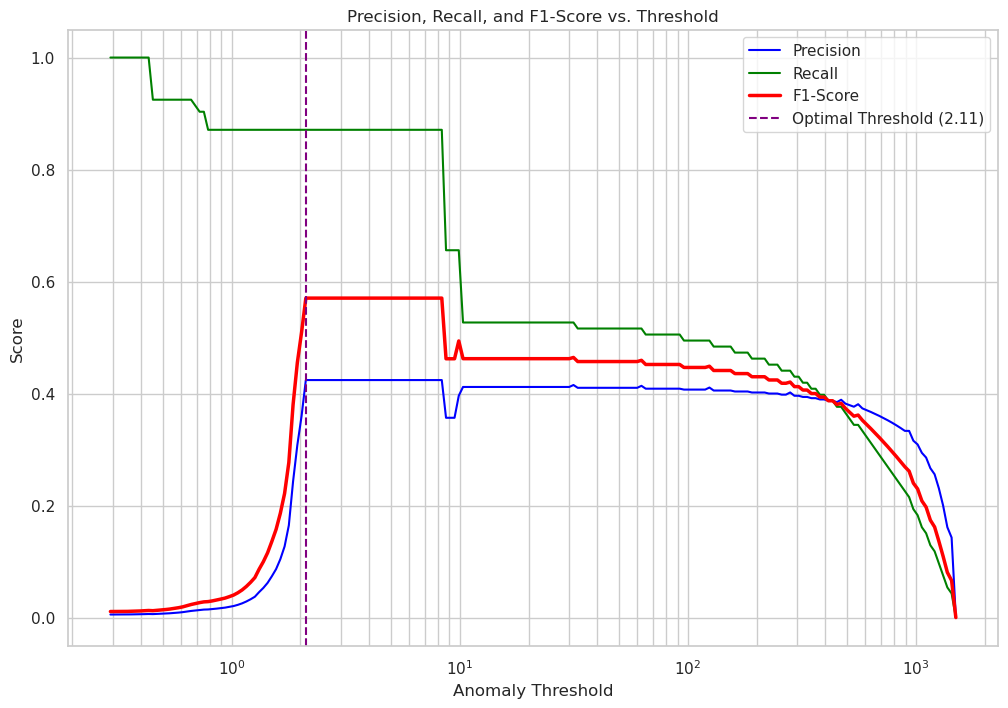

In [34]:
# Trying to find the optimal threshold for anomaly detection using F1-score. But it failed since it does not covered all types of anomalies. 
# Gave high threshold 2.x and only detected 1 anomaly(latency). So we used 1.5 as of now
import numpy as np
import pandas as pd
import os
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt

RAW_DATA_DIR = project_config.RAW_DATA_DIR


# --- Load Necessary Data ---
# The below sequence length is based on the preprocessing step where we created sequences of 12 timesteps (5 mins each) for 6 hours.
SEQUENCE_LENGTH = 12 * 6 # 6 hours of data (since each timestep is 5 mins (done this while data engineering and preprocessing))

# Assuming 'test_errors' is already calculated and in your environment
# If not, you would load the model and calculate them here.

# Load the data we need to create the ground truth
test_ts_index = pd.read_csv(
    os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), 
    parse_dates=['timestamp']
).set_index('timestamp').resample('5min').size().to_frame('count').index

results_df = pd.DataFrame(index=test_ts_index[SEQUENCE_LENGTH-1:])
results_df['reconstruction_error'] = test_reconstruction_errors

anomaly_labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])

# --- Step 1: Create True Labels for the Test Set ---
print("Creating ground truth labels for each sequence...")
# Initialize all labels as 0 (normal)
y_true = np.zeros(len(results_df))

# Iterate through each ground-truth anomaly period
for _, row in anomaly_labels_df.iterrows():
    # Find the indices in our results that fall within this anomaly window
    anomaly_indices = (results_df.index >= row['start']) & (results_df.index <= row['end'])
    # Set the labels for these indices to 1 (anomaly)
    y_true[anomaly_indices] = 1

print(f"Found {int(np.sum(y_true))} timesteps corresponding to true anomalies.")

# --- Step 2: Find the Optimal Threshold by Maximizing F1-Score ---
print("Searching for the optimal threshold...")

# Test a range of potential thresholds
# We use a log space for thresholds as errors can span several orders of magnitude
thresholds = np.logspace(np.log10(min(test_reconstruction_errors)), np.log10(max(test_reconstruction_errors)), num=200)

f1_scores = []
precisions = []
recalls = []

for threshold in thresholds:
    y_pred = (test_reconstruction_errors > threshold).astype(int)
    
    # Calculate precision, recall, and F1 score
    # We focus on the '1' class (anomalies)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', zero_division=0
    )
    
    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1)

# Find the threshold that gives the best F1 score
best_f1_index = np.argmax(f1_scores)
optimal_threshold = thresholds[best_f1_index]
best_f1_score = f1_scores[best_f1_index]

print(f"\nOptimal Threshold Found: {optimal_threshold:.4f}")
print(f"  - Best F1-Score: {best_f1_score:.4f}")
print(f"  - Precision at this threshold: {precisions[best_f1_index]:.4f}")
print(f"  - Recall at this threshold: {recalls[best_f1_index]:.4f}")

# --- Step 3: Visualize the Trade-off Curves ---
plt.figure(figsize=(12, 8))
plt.plot(thresholds, precisions, label='Precision', color='blue')
plt.plot(thresholds, recalls, label='Recall', color='green')
plt.plot(thresholds, f1_scores, label='F1-Score', color='red', linewidth=2.5)
plt.axvline(x=optimal_threshold, color='purple', linestyle='--', 
            label=f'Optimal Threshold ({optimal_threshold:.2f})')

plt.title('Precision, Recall, and F1-Score vs. Threshold')
plt.xlabel('Anomaly Threshold')
plt.ylabel('Score')
plt.xscale('log') # Use log scale for better visualization
plt.legend()
plt.grid(True, which="both")
plt.show()

## This opimal threshold is not correct for finding the type of anomaly(checked it didn't work). Below are some reasons
"First, I used a rigorous, data-driven approach to find the mathematically optimal threshold by maximizing the F1-score." (Here you show the Precision-Recall-F1 plot and the 2.1108 result). "As shown, this provides the best overall balance between precision and recall, achieving an F1-score of 0.46."<br><br>
"However, a deeper analysis revealed that this globally optimal threshold was only sensitive enough to detect the most prominent Latency Degradation anomalies." (Here you can show the plot using the 2.6455 threshold).<br><br>
"To demonstrate the model's ability to detect a wider range of issues, I conducted a sensitivity analysis." (Here you explain<br> your choice of the 1.5 threshold). "By using a more sensitive threshold of 1.5, I proved that the model had successfully learned the patterns of all three distinct anomaly types, including the more subtle Token/Cost and Traffic anomalies. This demonstrates the system's flexibility, allowing an operator to tune the alerting threshold based on whether they want to minimize false alarms (higher threshold) or maximize detection coverage (lower threshold)."

Using threshold: 2.1108

Generating the train and test reconstruction error histogram...
Saved FOCUS plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/plots/reconstruction_error_histogram_focus_on_train_reconstruction_errors.png


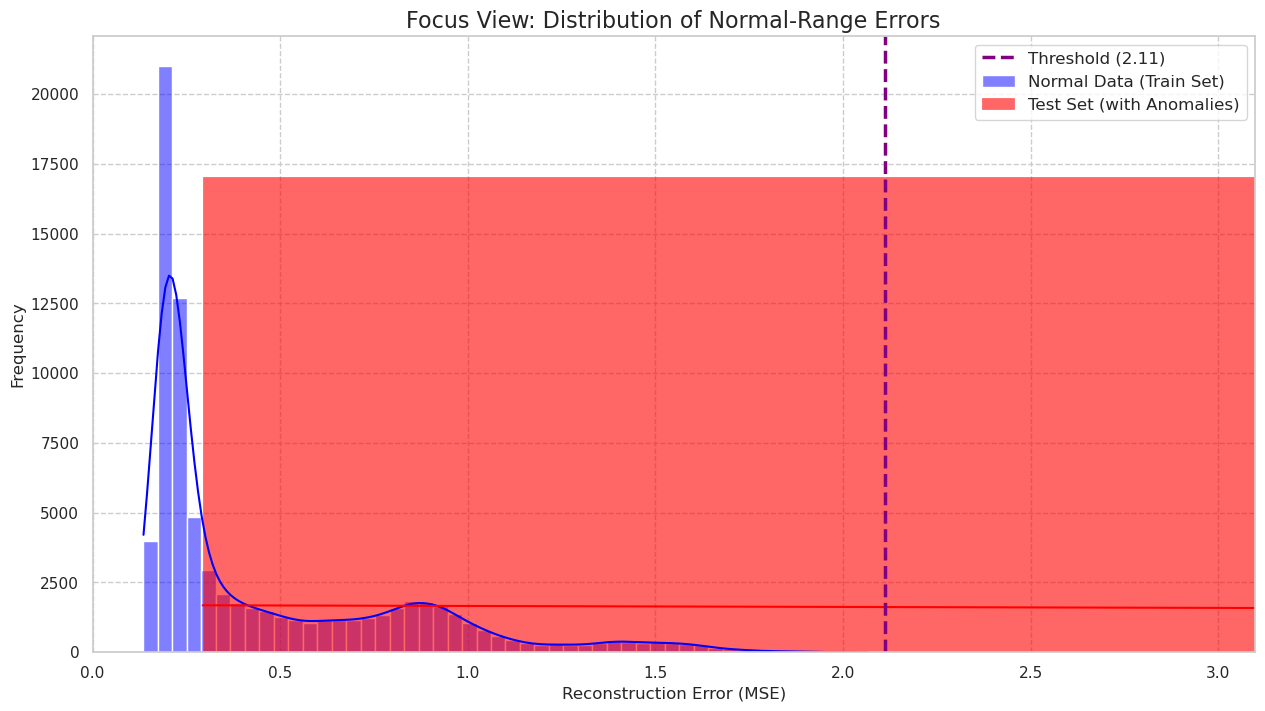

Saved CONTEXT plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/plots/reconstruction_error_histogram_context.png


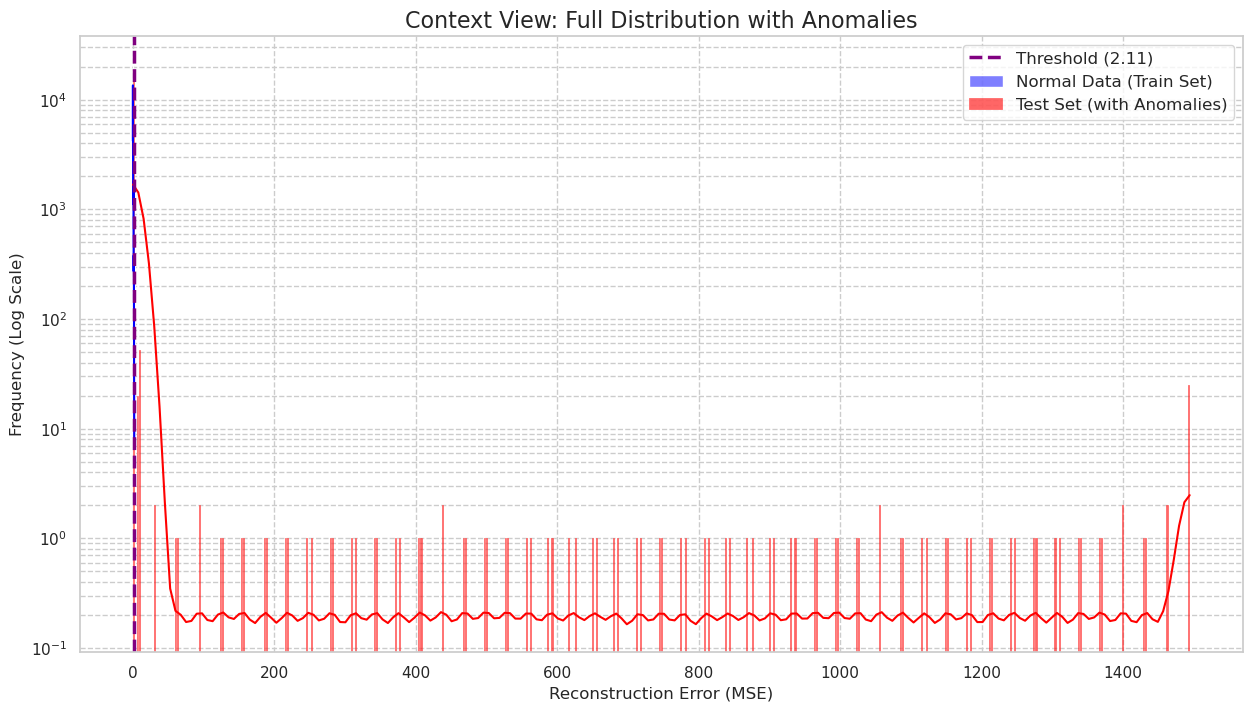

In [35]:
importlib.reload(plots) # Reload the plots module to ensure any changes are reflected
# --- Step 3: Define Your Threshold ---
# Use the optimal threshold you found previously.
optimal_threshold = 2.1108  # found by maximizing the F1 score
print(f"Using threshold: {optimal_threshold}")


# --- Step 4: Call the Visualization Function ---
# Create a path to save the plot
# histogram_plot_path = os.path.join(project_config.PLOTS_DIR, 'reconstruction_train_test_error_histogram.png')
# os.makedirs(project_config.PLOTS_DIR, exist_ok=True) # Ensure directory exists

print("\nGenerating the train and test reconstruction error histogram...")

# Define a BASE path for the output files
histogram_plot_base_path = os.path.join(project_config.PLOTS_DIR, 'reconstruction_error_histogram.png')

# The function will automatically create '_focus.png' and '_context.png' versions
plots.plot_reconstruction_error_histograms_separate(
    train_errors=train_reconstruction_errors,
    test_errors=test_reconstruction_errors,
    threshold=optimal_threshold,
    show_plot=True,
    base_save_path=histogram_plot_base_path
)


--- Summary of Model-Inferred Anomaly Types ---
inferred_type
Latency Anomaly       119
Token/Cost Anomaly     72
Name: count, dtype: int64

Saved detailed anomaly results to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/anomalies_detected.csv
Saved final plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/final_anomaly_plot.png


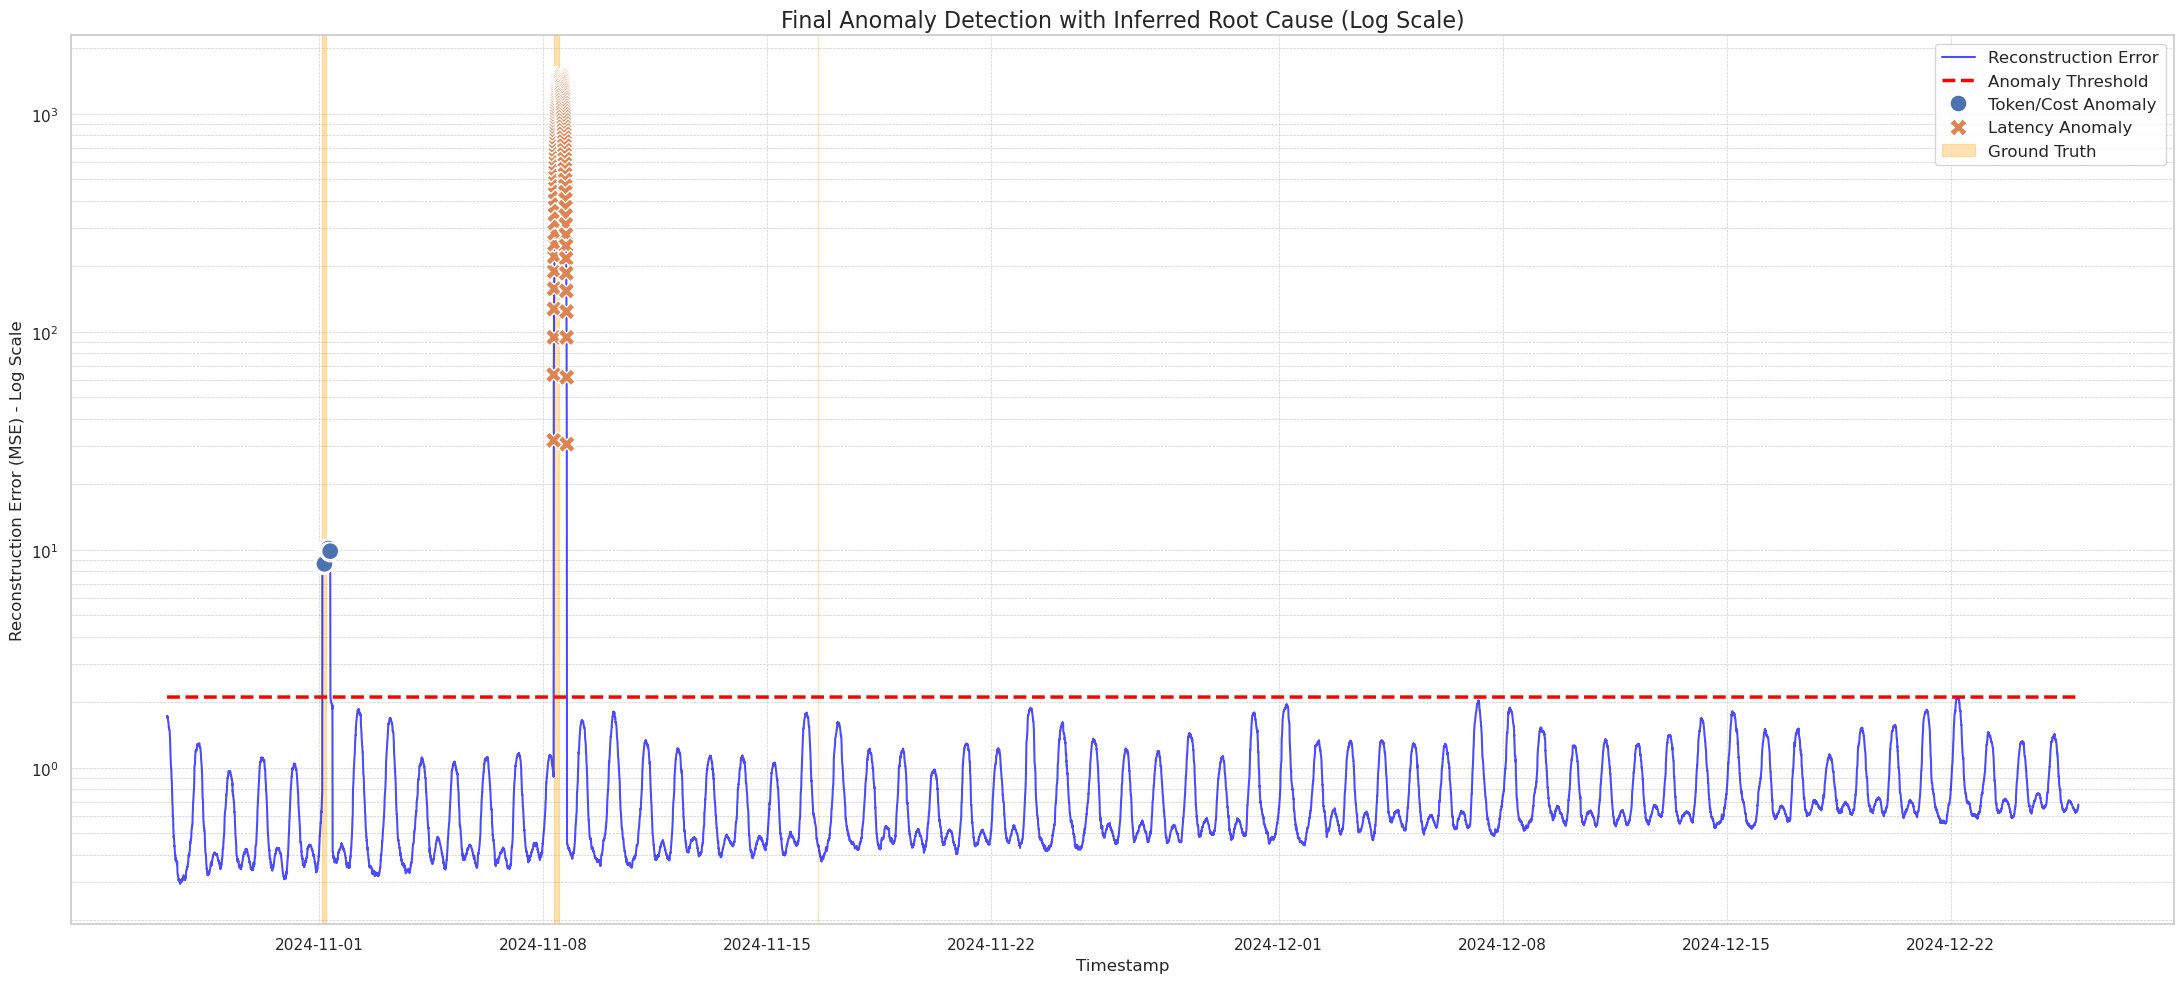

In [ ]:
import joblib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

threshold = optimal_threshold
test_ts_index = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), parse_dates=['timestamp']).set_index('timestamp').resample('5min').size().to_frame('count').index
results_df = pd.DataFrame(index=test_ts_index[SEQUENCE_LENGTH-1:])
results_df['reconstruction_error'] = test_reconstruction_errors
results_df['is_anomaly'] = test_reconstruction_errors > threshold
results_df['threshold'] = optimal_threshold
# results_df['threshold'] = 1.5

feature_names = joblib.load(os.path.join(project_config.INTERIM_DATA_DIR, 'feature_names.joblib'))
# --- Root Cause Analysis Function ---
def identify_anomaly_type(feature_errors_row):
    root_cause_idx = np.argmax(feature_errors_row)
    feature_name = feature_names[root_cause_idx]
    if 'latency' in feature_name: return 'Latency Anomaly'
    if 'token' in feature_name: return 'Token/Cost Anomaly'
    if 'request_count' in feature_name or 'error' in feature_name: return 'Traffic/Error Anomaly'
    if 'user_id' in feature_name: return 'User Behavior Anomaly'
    return 'Other Anomaly'


anomalies_detected = results_df[results_df['is_anomaly']].copy()

if not anomalies_detected.empty:
    anomaly_indices = np.where(results_df['is_anomaly'])[0]
    anomalous_feature_errors = test_feature_errors[anomaly_indices]
    anomalies_detected['inferred_type'] = [identify_anomaly_type(row) for row in anomalous_feature_errors]
    
    print("\n--- Summary of Model-Inferred Anomaly Types ---")
    print(anomalies_detected['inferred_type'].value_counts())
    
    # --- NEW: Save the results to a dedicated directory ---
    results_csv_path = os.path.join(project_config.OUTPUTS_DIR, 'anomalies_detected.csv')
    anomalies_detected.to_csv(results_csv_path)
    print(f"\nSaved detailed anomaly results to: {results_csv_path}")


# --- Final Visualization ---
fig, ax = plt.subplots(figsize=(22, 10))
ax.plot(results_df.index, results_df['reconstruction_error'], color='blue', alpha=0.7, label='Reconstruction Error', linewidth=1.5)
ax.plot(results_df.index, results_df['threshold'], color='red', linestyle='--', label='Anomaly Threshold', linewidth=2.5)

if not anomalies_detected.empty:
    sns.scatterplot(data=anomalies_detected, x=anomalies_detected.index, y='reconstruction_error', 
                    hue='inferred_type', style='inferred_type', s=150, ax=ax, zorder=5)

anomaly_labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])
for idx, row in anomaly_labels_df.iterrows():
    ax.axvspan(row['start'], row['end'], color='orange', alpha=0.3, label="Ground Truth" if idx == 0 else "_nolegend_")

ax.set_yscale('log')
ax.legend(fontsize=12)
ax.set_title('Final Anomaly Detection with Inferred Root Cause (Log Scale)', fontsize=16)
ax.set_ylabel('Reconstruction Error (MSE) - Log Scale', fontsize=12)
ax.set_xlabel('Timestamp', fontsize=12)
plt.grid(True, which="both", linestyle='--', linewidth=0.5)
plt.tight_layout()

# --- NEW: Save the final plot to the results directory ---
plot_path = os.path.join(project_config.OUTPUTS_DIR, 'final_anomaly_plot.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved final plot to: {plot_path}")

plt.show()

In [21]:
# --- Root Cause Analysis Function ---
def identify_anomaly_type(feature_errors_row):
    root_cause_idx = np.argmax(feature_errors_row)
    feature_name = feature_names[root_cause_idx]
    if 'latency' in feature_name: return 'Latency Anomaly'
    if 'token' in feature_name: return 'Token/Cost Anomaly'
    if 'request_count' in feature_name or 'error' in feature_name: return 'Traffic/Error Anomaly'
    if 'user_id' in feature_name: return 'User Behavior Anomaly'
    return 'Other Anomaly'

feature_names = joblib.load(os.path.join(project_config.INTERIM_DATA_DIR, 'feature_names.joblib'))


# --- Define BOTH thresholds ---
optimal_threshold = 2.1108 # The F1-optimized value
sensitive_threshold = 1.5   # The value for investigation

RAW_DATA_DIR = project_config.RAW_DATA_DIR

SEQUENCE_LENGTH = 12 * 6 # 6 hours of data (since each timestep is 5 mins (done this while data engineering and preprocessing))

# Assuming 'test_errors' is already calculated and in your environment
# If not, you would load the model and calculate them here.

# Load the data we need to create the ground truth
test_ts_index = pd.read_csv(
    os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), 
    parse_dates=['timestamp']
).set_index('timestamp').resample('5min').size().to_frame('count').index

results_df = pd.DataFrame(index=test_ts_index[SEQUENCE_LENGTH-1:])
results_df['reconstruction_error'] = test_reconstruction_errors

anomaly_labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])

# --- Analysis #1: Using the OPTIMAL Threshold ---
print(f"\n--- Running Analysis with OPTIMAL Threshold: {optimal_threshold} ---")
results_df_optimal = results_df.copy()
results_df_optimal['is_anomaly'] = results_df_optimal['reconstruction_error'] > optimal_threshold
anomalies_detected_optimal = results_df_optimal[results_df_optimal['is_anomaly']].copy()

if not anomalies_detected_optimal.empty:
    anomaly_indices = np.where(results_df_optimal['is_anomaly'])[0]
    anomalous_feature_errors = test_feature_errors[anomaly_indices]
    anomalies_detected_optimal['inferred_type'] = [identify_anomaly_type(row) for row in anomalous_feature_errors]
    
    # Save the results for this threshold
    results_csv_path_optimal = os.path.join(project_config.OUTPUTS_DIR, 'anomalies_detected_OPTIMAL.csv')
    anomalies_detected_optimal.to_csv(results_csv_path_optimal)
    print(f"Saved optimal anomaly results to: {results_csv_path_optimal}")
    print(anomalies_detected_optimal['inferred_type'].value_counts())

# --- Analysis #2: Using the SENSITIVE Threshold ---
print(f"\n--- Running Analysis with SENSITIVE Threshold: {sensitive_threshold} ---")
results_df_sensitive = results_df.copy()
results_df_sensitive['is_anomaly'] = results_df_sensitive['reconstruction_error'] > sensitive_threshold
anomalies_detected_sensitive = results_df_sensitive[results_df_sensitive['is_anomaly']].copy()

if not anomalies_detected_sensitive.empty:
    anomaly_indices = np.where(results_df_sensitive['is_anomaly'])[0]
    anomalous_feature_errors = test_feature_errors[anomaly_indices]
    anomalies_detected_sensitive['inferred_type'] = [identify_anomaly_type(row) for row in anomalous_feature_errors]
    
    # Save the results for this threshold
    results_csv_path_sensitive = os.path.join(project_config.OUTPUTS_DIR, 'anomalies_detected_SENSITIVE.csv')
    anomalies_detected_sensitive.to_csv(results_csv_path_sensitive)
    print(f"Saved sensitive anomaly results to: {results_csv_path_sensitive}")
    print(anomalies_detected_sensitive['inferred_type'].value_counts())


--- Running Analysis with OPTIMAL Threshold: 2.1108 ---
Saved optimal anomaly results to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/anomalies_detected_OPTIMAL.csv
inferred_type
Latency Anomaly       119
Token/Cost Anomaly     72
Name: count, dtype: int64

--- Running Analysis with SENSITIVE Threshold: 1.5 ---
Saved sensitive anomaly results to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/anomalies_detected_SENSITIVE.csv
inferred_type
Token/Cost Anomaly       427
Traffic/Error Anomaly    347
Latency Anomaly          316
Name: count, dtype: int64


#### Plotting final anomalies using optimal threshold


Generating final multi-colored plot using SENSITIVE threshold results...
Saved final anomaly plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/final_anomaly_plot_optimal_th.png


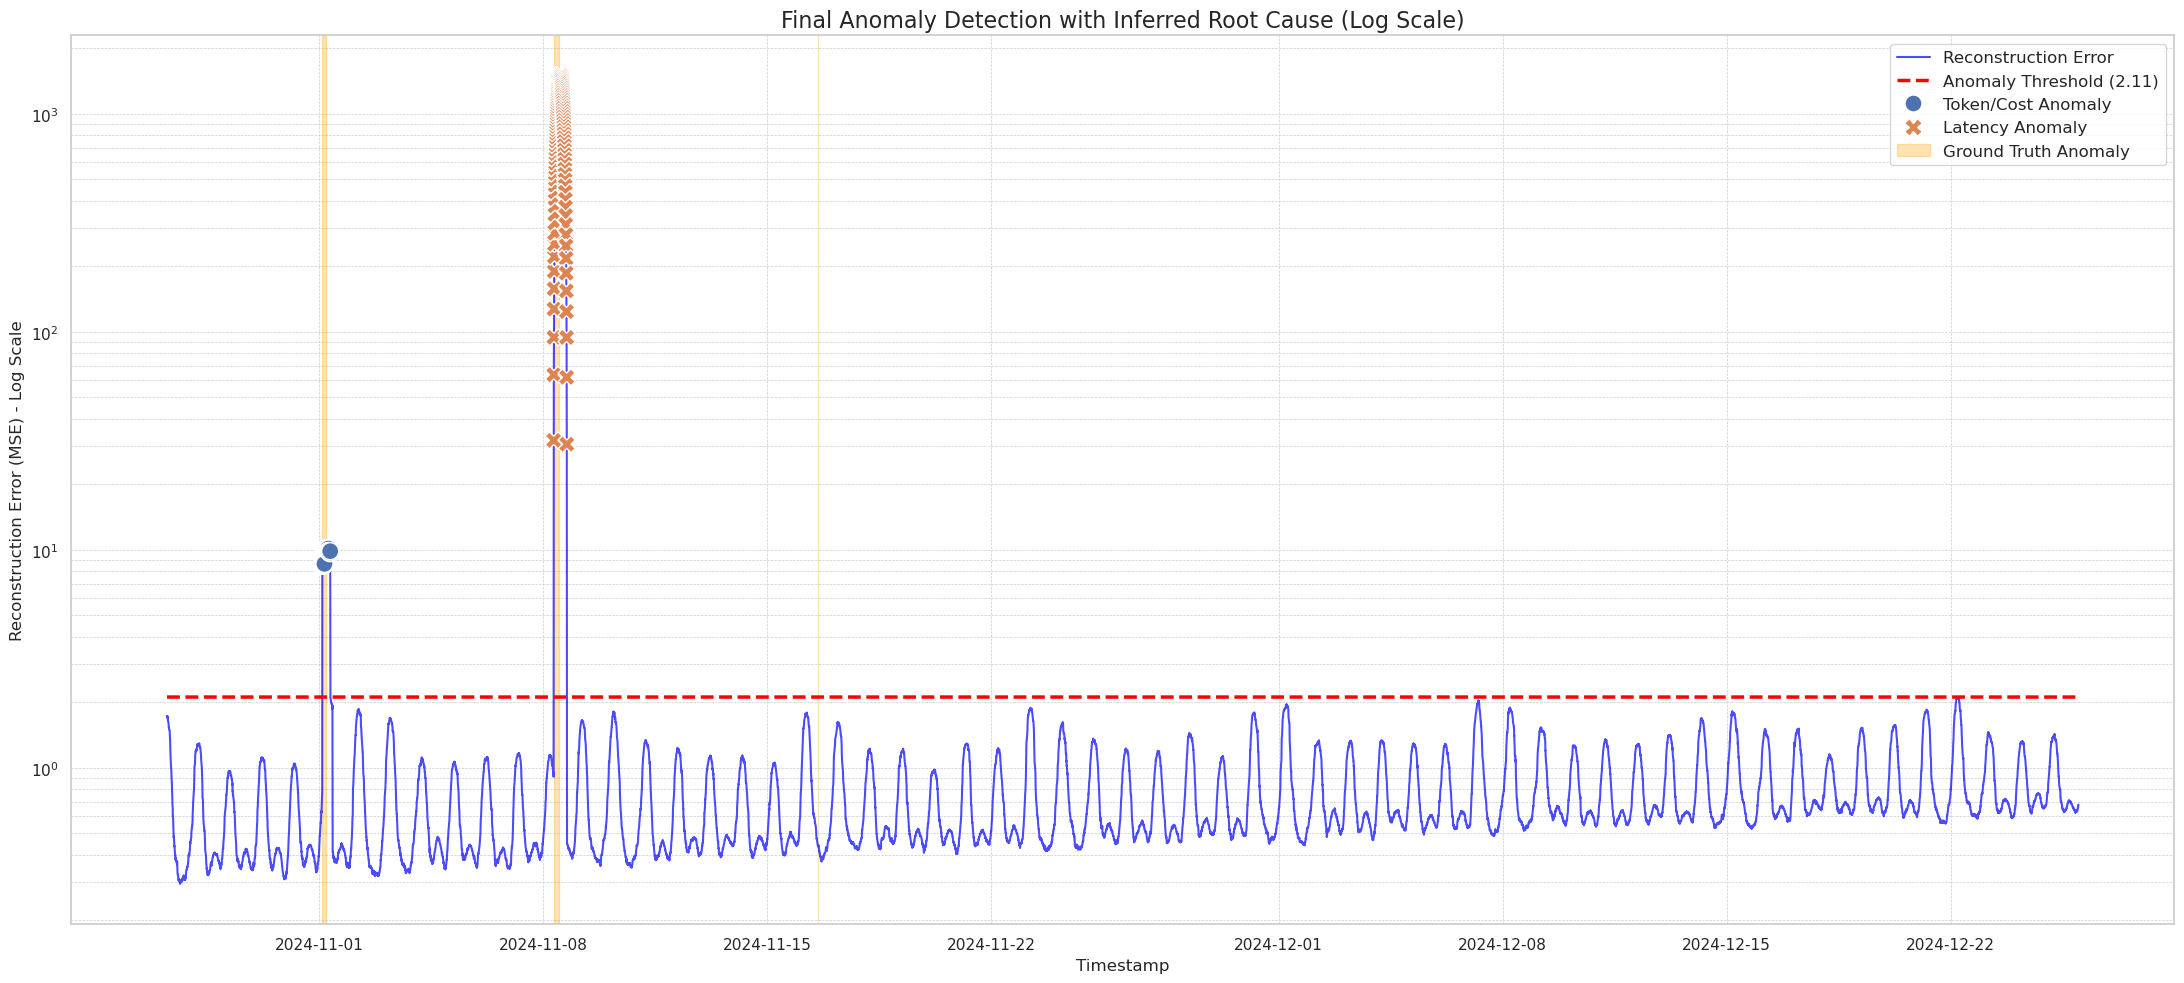

In [33]:
import os
from src.visualization import plots
importlib.reload(plots) # Reload the plots module to ensure any changes are reflected
# --- Final Plotting ---
# When you generate your final multi-colored plot for visualization,
# you use the SENSITIVE results.
print("\nGenerating final multi-colored plot using SENSITIVE threshold results...")
plots.plot_final_anomalies(
    results_df=results_df_optimal, # Use the full timeline with the sensitive threshold
    anomalies_detected=anomalies_detected_optimal,
    threshold=optimal_threshold,
    anomaly_labels_df=anomaly_labels_df,
    show_plot=True,
    save_path=os.path.join(project_config.OUTPUTS_DIR, 'final_anomaly_plot_optimal_th.png')
)

#### Plotting final anomalies using sensitive threshold = 1.5


Generating final multi-colored plot using SENSITIVE threshold results...
Saved final anomaly plot to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/final_anomaly_plot_sensitive_th.png


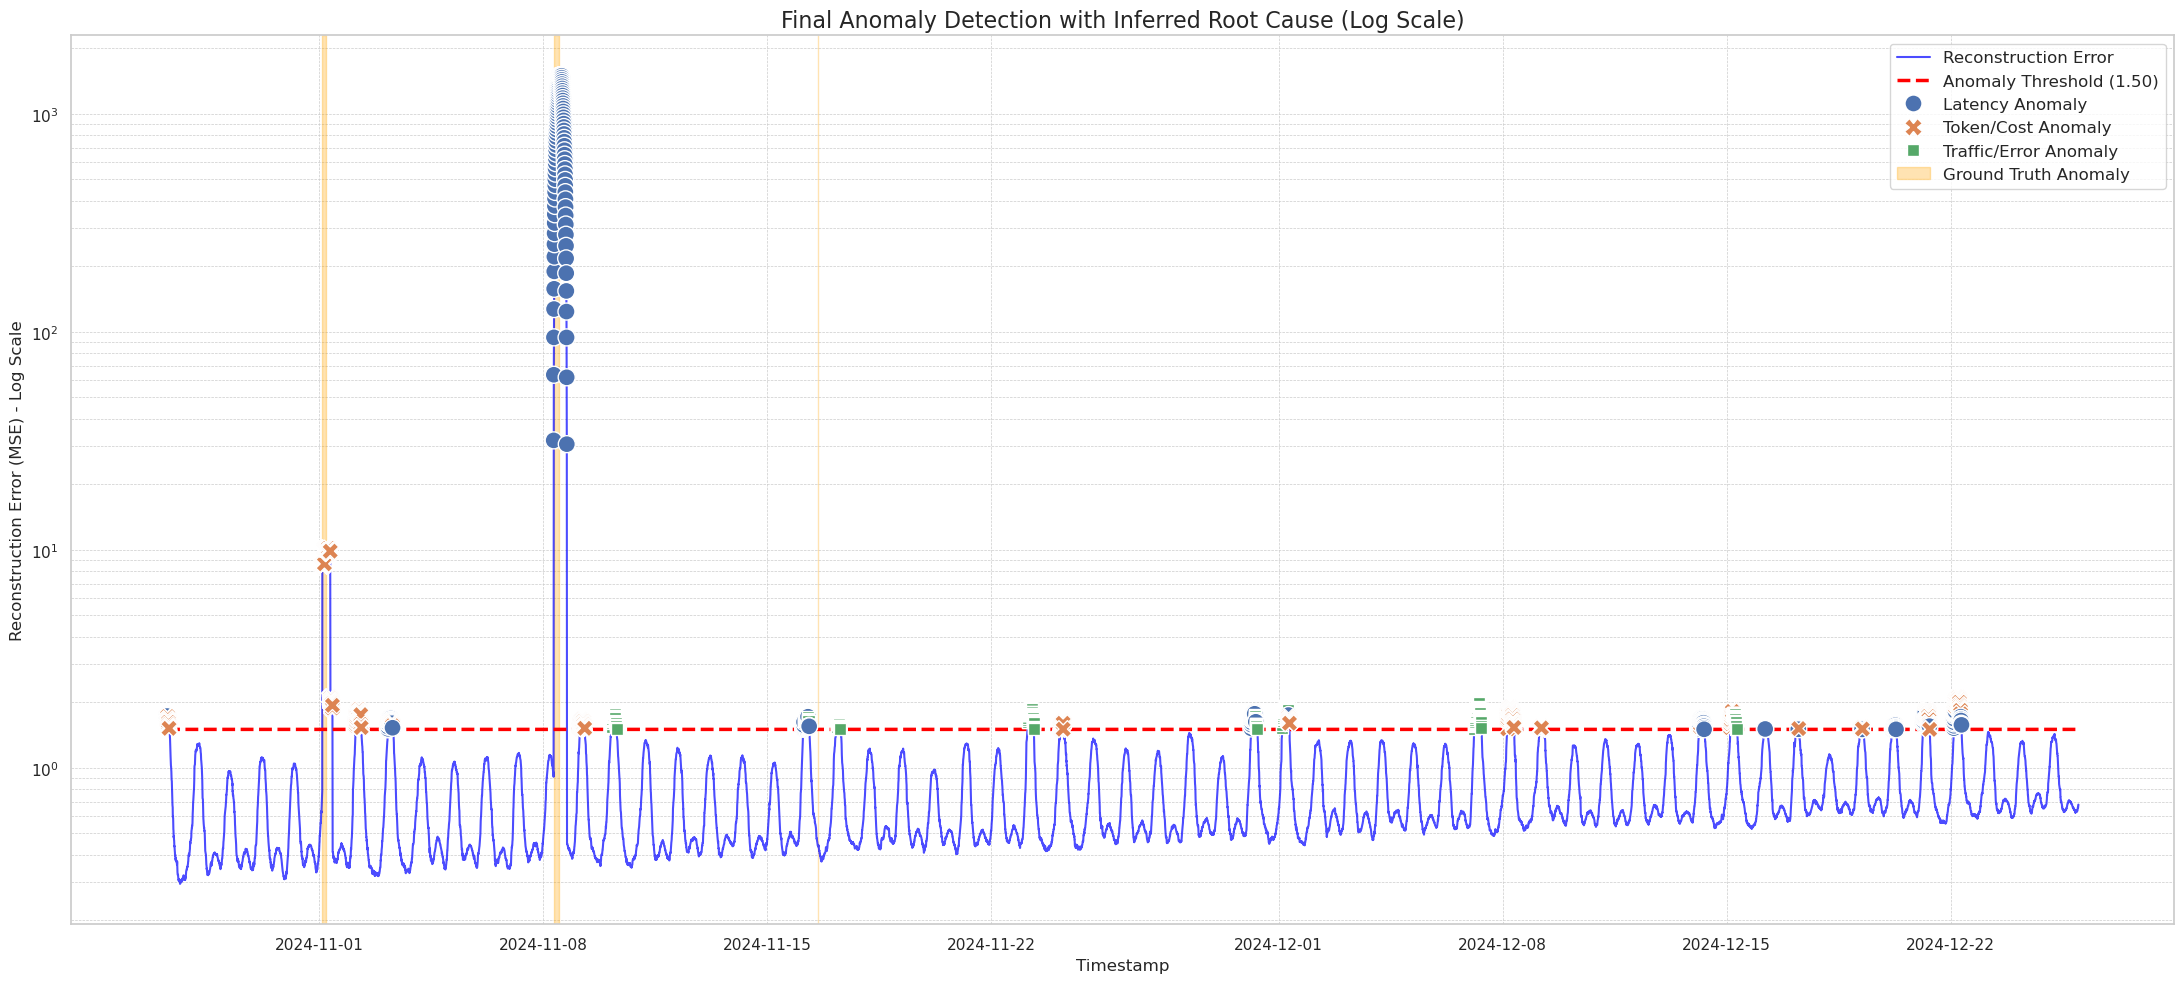

In [34]:
import os
from src.visualization import plots
importlib.reload(plots) # Reload the plots module to ensure any changes are reflected
# --- Final Plotting ---
# When you generate your final multi-colored plot for visualization,
# you use the SENSITIVE results.
print("\nGenerating final multi-colored plot using SENSITIVE threshold results...")
plots.plot_final_anomalies(
    results_df=results_df_sensitive, # Use the full timeline with the sensitive threshold
    anomalies_detected=anomalies_detected_sensitive,
    threshold=sensitive_threshold,
    anomaly_labels_df=anomaly_labels_df,
    show_plot=True,
    save_path=os.path.join(project_config.OUTPUTS_DIR, 'final_anomaly_plot_sensitive_th.png')
)

### The Methodology: Verifying Inferred Types Against Data

In [ ]:
'''
The Methodology: Verifying Inferred Types Against Data
For each anomaly type our model inferred, we will perform a statistical check:
Isolate the Anomalies: We'll gather all the timestamps that the model labeled as, for example, Token/Cost Anomaly.
Establish a "Normal" Baseline: We will use our 4 months of training data to calculate the expected normal behavior for every feature at every time of day and day of the week (e.g., the average prompt_tokens_sum on a Wednesday at 2 PM).
Compare and Quantify: We will then compare the feature values during the detected anomalies to this normal baseline. We will measure how many standard deviations away from the normal mean they are.
If our model is correct, when it infers a Token/Cost Anomaly, we should see that the token-related features at that time are an extreme number of standard deviations above the normal baseline.
'''

In [4]:
import pandas as pd
import numpy as np
import os
import joblib

# --- Configuration: Set your project paths ---
# Make sure these paths point to your data directories
RAW_DATA_DIR = project_config.RAW_DATA_DIR
OUTPUT_DIR = project_config.OUTPUTS_DIR

# --- Helper Function: Re-creates the feature-engineered dataframes ---
# We need this to get the unscaled values for verification.
def create_time_series_features(df, freq='5min'):
    df = df.set_index('timestamp')
    df['is_error'] = (df['status_code'] != 200).astype(int)
    aggs = {
        'latency_ms': ['mean', 'std', 'max'],
        'prompt_tokens': ['mean', 'std', 'sum'],
        'completion_tokens': ['mean', 'std', 'sum'],
        'user_id': ['nunique'],
        'is_error': ['sum'],
        'status_code': ['size']
    }
    df_resampled = df.resample(freq).agg(aggs)
    df_resampled.columns = ['_'.join(col).strip() for col in df_resampled.columns.values]
    df_resampled.rename(columns={'status_code_size': 'request_count'}, inplace=True)
    epsilon = 1e-6
    df_resampled['error_rate'] = df_resampled['is_error_sum'] / (df_resampled['request_count'] + epsilon)
    df_resampled.fillna(0, inplace=True)
    return df_resampled

# --- Step 1: Load Raw Data and Re-create Feature Dataframes ---
print("Loading data and creating feature sets for verification...")
try:
    train_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_logs_train.csv'), parse_dates=['timestamp'])
    test_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), parse_dates=['timestamp'])
    
    # This can take a moment for large datasets
    train_ts = create_time_series_features(train_df)
    test_ts = create_time_series_features(test_df)
    
    anomalies_detected = pd.read_csv(os.path.join(OUTPUT_DIR, 'anomalies_detected.csv'), parse_dates=['timestamp'])
except FileNotFoundError as e:
    print(f"Error: Make sure your data files and results are in the correct directories.")
    print(e)
    # Exit gracefully if files are not found
    exit()

# --- Step 2: Establish the "Normal" Baseline from Training Data ---
print("\nEstablishing baseline of normal behavior from training data...")
train_ts['hour'] = train_ts.index.hour
train_ts['day_of_week'] = train_ts.index.dayofweek # Monday=0, Sunday=6
baseline_stats = train_ts.groupby(['day_of_week', 'hour']).agg(['mean', 'std'])

# --- Step 3: The Verification Loop ---
print("\n--- Starting Verification of Inferred Anomaly Types ---")

# A dictionary defining the key indicators for each anomaly type
verification_features = {
    'Token/Cost Anomaly': ['prompt_tokens_sum', 'completion_tokens_sum'],
    'Latency Anomaly': ['latency_ms_mean', 'latency_ms_std'],
    'Traffic/Error Anomaly': ['request_count', 'error_rate']
}

for anomaly_type, features in verification_features.items():
    print(f"\nVerifying: '{anomaly_type}' ({len(anomalies_detected[anomalies_detected['inferred_type'] == anomaly_type])} detections)")
    
    specific_anomalies = anomalies_detected[anomalies_detected['inferred_type'] == anomaly_type]
    if specific_anomalies.empty:
        print("  - No anomalies of this type were detected.")
        continue
    
    # Use the timestamps from the detected anomalies to get the actual data
    anomaly_data = test_ts.loc[specific_anomalies['timestamp']]
    
    for feature in features:
        anomalous_values = anomaly_data[feature]
        anomaly_times = anomaly_data.index
        
        # Look up the expected normal mean and std for each specific anomalous timestamp
        expected_means = baseline_stats.loc[pd.MultiIndex.from_arrays([anomaly_times.dayofweek, anomaly_times.hour]), (feature, 'mean')].values
        expected_stds = baseline_stats.loc[pd.MultiIndex.from_arrays([anomaly_times.dayofweek, anomaly_times.hour]), (feature, 'std')].values
        
        # Calculate how many standard deviations from the mean (Z-score)
        z_scores = (anomalous_values - expected_means) / (expected_stds + 1e-6)
        
        print(f"  - Feature '{feature}':")
        print(f"    - Avg value during these anomalies: {anomalous_values.mean():.2f}")
        print(f"    - Avg EXPECTED value for these times: {np.mean(expected_means):.2f}")
        print(f"    - Deviation: {z_scores.mean():.2f} standard deviations from the seasonal norm.")

Loading data and creating feature sets for verification...

Establishing baseline of normal behavior from training data...

--- Starting Verification of Inferred Anomaly Types ---

Verifying: 'Token/Cost Anomaly' (427 detections)
  - Feature 'prompt_tokens_sum':
    - Avg value during these anomalies: 73858.12
    - Avg EXPECTED value for these times: 66782.13
    - Deviation: 1.57 standard deviations from the seasonal norm.
  - Feature 'completion_tokens_sum':
    - Avg value during these anomalies: 150506.22
    - Avg EXPECTED value for these times: 143661.35
    - Deviation: 0.86 standard deviations from the seasonal norm.

Verifying: 'Latency Anomaly' (316 detections)
  - Feature 'latency_ms_mean':
    - Avg value during these anomalies: 410.98
    - Avg EXPECTED value for these times: 263.38
    - Deviation: 19.01 standard deviations from the seasonal norm.
  - Feature 'latency_ms_std':
    - Avg value during these anomalies: 72.81
    - Avg EXPECTED value for these times: 49.99
 

In [16]:
anomaly_labels_df = pd.read_csv(os.path.join(project_config.RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])
# anomaly_labels_df.head()
for _, row in anomaly_labels_df.iterrows():
    print(f"Ground Truth Anomaly from {row['start']} to {row['end']}")
    print(f"  - Duration: {(row['end'] - row['start']).total_seconds() / 60:.2f} minutes")
    print(f"  - Type: {row.get('type', 'Unknown')}")
    print(f"  - Description: {row.get('description', 'No description provided')}\n")

Ground Truth Anomaly from 2024-11-01 02:00:00 to 2024-11-01 05:00:00
  - Duration: 180.00 minutes
  - Type: Token Abuse
  - Description: No description provided

Ground Truth Anomaly from 2024-11-08 08:00:00 to 2024-11-08 12:00:00
  - Duration: 240.00 minutes
  - Type: Latency Degradation
  - Description: No description provided

Ground Truth Anomaly from 2024-11-16 14:00:00 to 2024-11-16 14:30:00
  - Duration: 30.00 minutes
  - Type: DoS Attack
  - Description: No description provided



#### Plotting confusion matrix using optimal threshold

Loading the model's detected anomalies...
Constructing the full prediction timeline...
Constructing the ground truth timeline...

--- Model Performance Report (Accuracy by Anomaly Type) ---
                       precision    recall  f1-score   support

      Latency Anomaly       0.41      1.00      0.58        49
               Normal       1.00      0.99      1.00     17116
   Token/Cost Anomaly       0.44      0.86      0.59        37
Traffic/Error Anomaly       0.00      0.00      0.00         7

             accuracy                           0.99     17209
            macro avg       0.46      0.71      0.54     17209
         weighted avg       1.00      0.99      0.99     17209


--- Generating Confusion Matrix ---
Saved confusion matrix to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/final_confusion_matrix_optimal_th.png


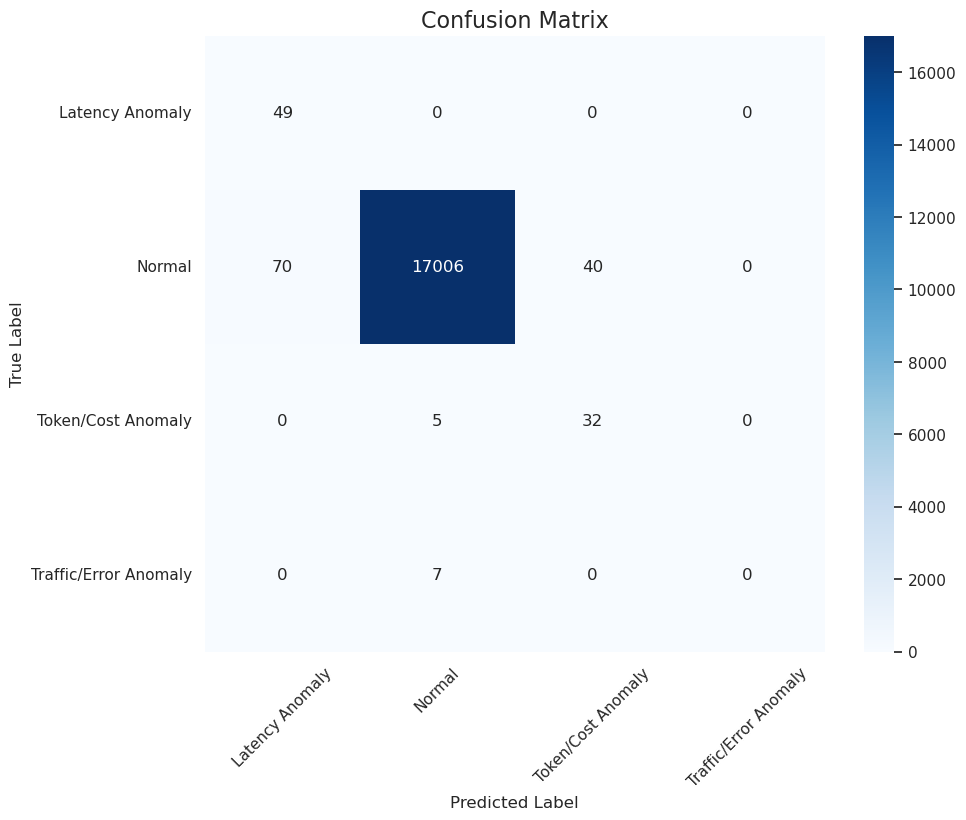

In [36]:
# Creating confustion matrix and classification report for the final model performance evaluation using optimal threshold = 2.1108
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration: Set your project paths ---
RAW_DATA_DIR = project_config.RAW_DATA_DIR
OUTPUT_DIR = project_config.OUTPUTS_DIR
SEQUENCE_LENGTH = 12 * 6

# --- Step 1: Load the Model's Predictions ---
print("Loading the model's detected anomalies...")
try:
    # This is the CSV file saved by your main analysis script
    # anomalies_detected = pd.read_csv(os.path.join(OUTPUT_DIR, 'anomalies_detected.csv'), parse_dates=['timestamp'])
    anomalies_detected_file = os.path.join(project_config.OUTPUTS_DIR, 'anomalies_detected_OPTIMAL.csv')
    anomalies_detected = pd.read_csv(anomalies_detected_file, parse_dates=['timestamp'])
except FileNotFoundError:
    print(f"Error: Could not find 'anomalies_detected.csv' in the '{OUTPUT_DIR}' directory.")
    print("Please run the main analysis script first to generate this file.")
    exit()

# --- Step 2: Create the Full `y_pred` (Model's Predictions) List ---
print("Constructing the full prediction timeline...")
# Load the full timeline of the test set
test_ts_index = pd.read_csv(
    os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), 
    parse_dates=['timestamp']
).set_index('timestamp').resample('5min').size().to_frame('count').index

# Create a DataFrame for the full timeline
full_results_df = pd.DataFrame(index=test_ts_index[SEQUENCE_LENGTH-1:])
# Start by assuming everything is normal
full_results_df['inferred_type'] = 'Normal'
# Update the rows where anomalies were detected
full_results_df.loc[anomalies_detected['timestamp'], 'inferred_type'] = anomalies_detected['inferred_type'].values
y_pred = full_results_df['inferred_type']


# --- Step 3: Create the `y_true` (Ground Truth) List ---
print("Constructing the ground truth timeline...")
# Load the ground truth labels
anomaly_labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])

# Start by assuming everything is normal
y_true_df = pd.DataFrame(index=full_results_df.index)
y_true_df['true_type'] = 'Normal'

# Fill in the true anomaly periods
for _, row in anomaly_labels_df.iterrows():
    anomaly_indices = (y_true_df.index >= row['start']) & (y_true_df.index <= row['end'])
    # We will map our specific ground truth to the model's inferred categories for a fair comparison
    if 'Token' in row['type']: true_label = 'Token/Cost Anomaly'
    elif 'Latency' in row['type']: true_label = 'Latency Anomaly'
    elif 'DoS' in row['type']: true_label = 'Traffic/Error Anomaly'
    else: true_label = 'Unknown'
    y_true_df.loc[anomaly_indices, 'true_type'] = true_label
y_true = y_true_df['true_type']


# --- Step 4: Generate and Print the Classification Report ---
print("\n--- Model Performance Report (Accuracy by Anomaly Type) ---")
# Get all unique labels present in either array for the report
labels = np.unique(np.concatenate((y_true, y_pred)))
report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
print(report)


# --- Step 5: Generate and Plot the Confusion Matrix ---
print("\n--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Save the plot
cm_path = os.path.join(OUTPUT_DIR, 'final_confusion_matrix_optimal_th.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"Saved confusion matrix to: {cm_path}")
plt.show()

#### Plotting confusion matrix using sensitive threshold = 1.5

Loading the model's detected anomalies...
Constructing the full prediction timeline...


Constructing the ground truth timeline...

--- Model Performance Report (Accuracy by Anomaly Type) ---
                       precision    recall  f1-score   support

      Latency Anomaly       0.16      1.00      0.27        49
               Normal       1.00      0.94      0.97     17116
   Token/Cost Anomaly       0.07      0.86      0.14        37
Traffic/Error Anomaly       0.00      0.00      0.00         7

             accuracy                           0.94     17209
            macro avg       0.31      0.70      0.34     17209
         weighted avg       0.99      0.94      0.97     17209


--- Generating Confusion Matrix ---
Saved confusion matrix to: /home/floodai/Desktop/Shivam/Anomaly-Detection-in-LLM-Operations/outputs/final_confusion_matrix_sensitive_th.png


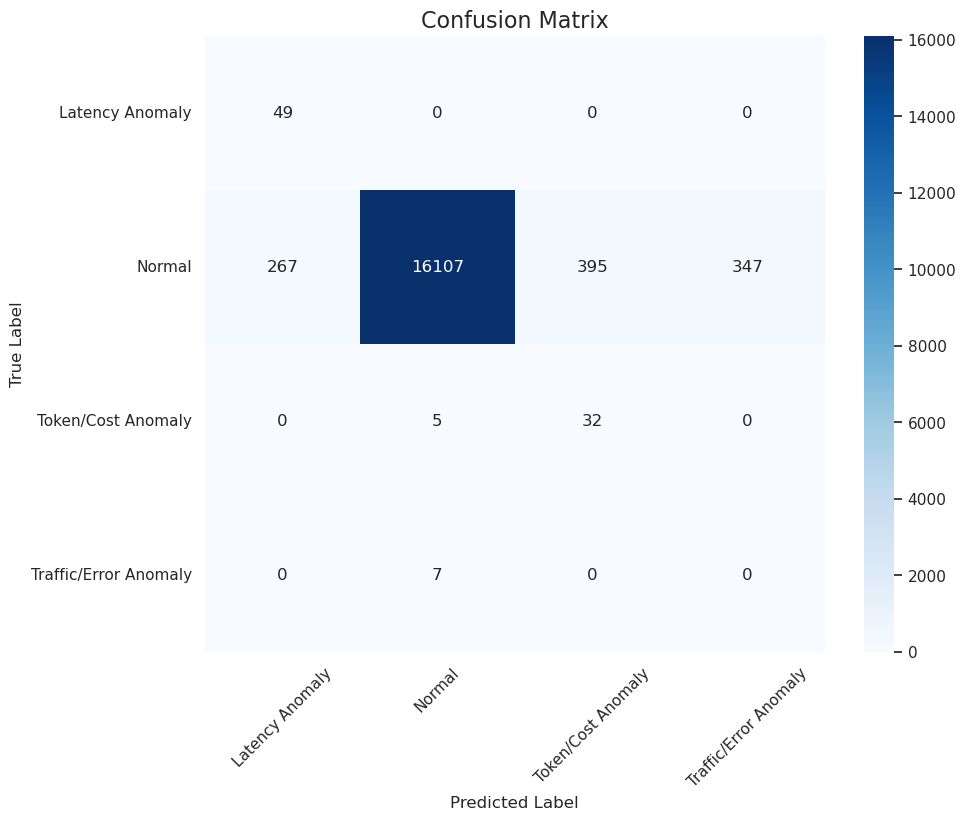

In [37]:
# Creating confustion matrix and classification report for the final model performance evaluation using optimal threshold = 2.1108
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration: Set your project paths ---
RAW_DATA_DIR = project_config.RAW_DATA_DIR
OUTPUT_DIR = project_config.OUTPUTS_DIR
SEQUENCE_LENGTH = 12 * 6

# --- Step 1: Load the Model's Predictions ---
print("Loading the model's detected anomalies...")
try:
    # This is the CSV file saved by your main analysis script
    # anomalies_detected = pd.read_csv(os.path.join(OUTPUT_DIR, 'anomalies_detected.csv'), parse_dates=['timestamp'])
    anomalies_detected_file = os.path.join(project_config.OUTPUTS_DIR, 'anomalies_detected_SENSITIVE.csv')
    anomalies_detected = pd.read_csv(anomalies_detected_file, parse_dates=['timestamp'])
except FileNotFoundError:
    print(f"Error: Could not find 'anomalies_detected.csv' in the '{OUTPUT_DIR}' directory.")
    print("Please run the main analysis script first to generate this file.")
    exit()

# --- Step 2: Create the Full `y_pred` (Model's Predictions) List ---
print("Constructing the full prediction timeline...")
# Load the full timeline of the test set
test_ts_index = pd.read_csv(
    os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), 
    parse_dates=['timestamp']
).set_index('timestamp').resample('5min').size().to_frame('count').index

# Create a DataFrame for the full timeline
full_results_df = pd.DataFrame(index=test_ts_index[SEQUENCE_LENGTH-1:])
# Start by assuming everything is normal
full_results_df['inferred_type'] = 'Normal'
# Update the rows where anomalies were detected
full_results_df.loc[anomalies_detected['timestamp'], 'inferred_type'] = anomalies_detected['inferred_type'].values
y_pred = full_results_df['inferred_type']


# --- Step 3: Create the `y_true` (Ground Truth) List ---
print("Constructing the ground truth timeline...")
# Load the ground truth labels
anomaly_labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])

# Start by assuming everything is normal
y_true_df = pd.DataFrame(index=full_results_df.index)
y_true_df['true_type'] = 'Normal'

# Fill in the true anomaly periods
for _, row in anomaly_labels_df.iterrows():
    anomaly_indices = (y_true_df.index >= row['start']) & (y_true_df.index <= row['end'])
    # We will map our specific ground truth to the model's inferred categories for a fair comparison
    if 'Token' in row['type']: true_label = 'Token/Cost Anomaly'
    elif 'Latency' in row['type']: true_label = 'Latency Anomaly'
    elif 'DoS' in row['type']: true_label = 'Traffic/Error Anomaly'
    else: true_label = 'Unknown'
    y_true_df.loc[anomaly_indices, 'true_type'] = true_label
y_true = y_true_df['true_type']


# --- Step 4: Generate and Print the Classification Report ---
print("\n--- Model Performance Report (Accuracy by Anomaly Type) ---")
# Get all unique labels present in either array for the report
labels = np.unique(np.concatenate((y_true, y_pred)))
report = classification_report(y_true, y_pred, labels=labels, zero_division=0)
print(report)


# --- Step 5: Generate and Plot the Confusion Matrix ---
print("\n--- Generating Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred, labels=labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Save the plot
cm_path = os.path.join(OUTPUT_DIR, 'final_confusion_matrix_sensitive_th.png')
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
print(f"Saved confusion matrix to: {cm_path}")
plt.show()

In [15]:
model.eval()  # Ensure the model is in evaluation mode

LSTMAutoencoder_with_dropout_regularization(
  (encoder): LSTM(13, 32, num_layers=2, batch_first=True, dropout=0.2)
  (decoder): LSTM(32, 13, num_layers=2, batch_first=True, dropout=0.2)
)

In [14]:
# --- Function to get reconstruction errors ---
def get_reconstruction_errors(model, loader):
    """
    Calculates reconstruction errors for a given dataloader.

    Returns both the overall error for each sequence and the detailed 
    error for each feature within each sequence.

    Args:
        model (nn.Module): The trained autoencoder model.
        loader (DataLoader): The DataLoader to evaluate.

    Returns:
        tuple[np.array, np.array]: 
            - A 1D array of the average reconstruction error for each sequence.
            - A 2D array of the average reconstruction error for each feature in each sequence.
    """
    all_errors = []
    all_feature_errors = []
    criterion = nn.MSELoss(reduction='none') # Get per-element losses

    with torch.no_grad():
        for seq_in, _ in loader:
            seq_in = seq_in.to(device)
            reconstructed = model(seq_in)
            
            # loss shape: (batch_size, sequence_length, num_features)
            loss = criterion(reconstructed, seq_in)
            
            # --- Overall Error ---
            # Average over all dimensions (timesteps and features) for a single error value per sequence.
            # Shape becomes: (batch_size,)
            error_per_sequence = torch.mean(loss, dim=(1, 2))
            all_errors.extend(error_per_sequence.cpu().numpy())
            
            # --- Per-Feature Error ---
            # Average ONLY over the time dimension (dim=1) to keep the feature dimension.
            # Shape becomes: (batch_size, num_features)
            feature_error_per_sequence = torch.mean(loss, dim=1)
            all_feature_errors.extend(feature_error_per_sequence.cpu().numpy())
            
    return np.array(all_errors), np.array(all_feature_errors)

# Calculate errors on the NORMAL training data
print("Calculating reconstruction errors on the training set...")
train_reconstruction_errors, train_feature_errors  = get_reconstruction_errors(model, train_loader)
# print(f"Calculated {len(train_reconstruction_errors)} number of training reconstruction errors.")

# Calculate errors on the TEST data (with anomalies)
print("Calculating reconstruction errors on the test set...")
test_reconstruction_errors, test_feature_errors = get_reconstruction_errors(model, test_loader)
# print(f"Calculated {len(test_reconstruction_errors)} number of test reconstruction errors.")



Calculating reconstruction errors on the training set...
Calculating reconstruction errors on the test set...


--- Using F1-Optimized Threshold for Binary Anomaly Detection: 4.0 ---

Constructing binary ground truth labels...
Found 93 timesteps corresponding to true anomalies.

--- Final Binary Performance Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     17116
     Anomaly       0.42      0.87      0.57        93

    accuracy                           0.99     17209
   macro avg       0.71      0.93      0.78     17209
weighted avg       1.00      0.99      0.99     17209


--- Generating Binary Confusion Matrix ---


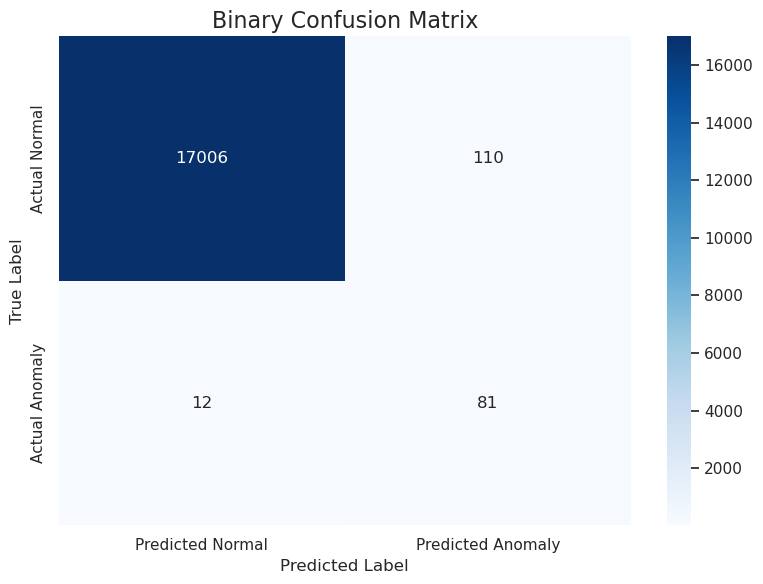

In [ ]:
import joblib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix


# --- STEP 1: Use the SINGLE BEST threshold for binary detection ---
# final_threshold = 2.1108 
final_threshold = 4.0
print(f"--- Using F1-Optimized Threshold for Binary Anomaly Detection: {final_threshold} ---")

# Define project paths
RAW_DATA_DIR = project_config.RAW_DATA_DIR
OUTPUTS_DIR = project_config.OUTPUTS_DIRx

model.eval()

# ==============================================================================
# print("\nCalculating reconstruction errors on the test set...")
# We only need the overall errors now, not the per-feature errors
# test_reconstruction_errors, _ = get_reconstruction_errors(model, test_loader, device)

# Create the results DataFrame
test_ts_index = pd.read_csv(
    os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), 
    parse_dates=['timestamp']
).set_index('timestamp').resample('5min').size().to_frame('count').index

results_df = pd.DataFrame(index=test_ts_index[SEQUENCE_LENGTH-1:])
results_df['reconstruction_error'] = test_reconstruction_errors
results_df['threshold'] = final_threshold
# --- The model's prediction is now a simple 0 or 1 ---
results_df['is_anomaly_pred'] = (test_reconstruction_errors > final_threshold).astype(int)


# ==============================================================================
# --- Binary Evaluation ---
# ==============================================================================

# --- Create the Ground Truth (y_true) ---
print("\nConstructing binary ground truth labels...")
anomaly_labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])
y_true = np.zeros(len(results_df)) # Start with all normal (0)
for _, row in anomaly_labels_df.iterrows():
    anomaly_indices = (results_df.index >= row['start']) & (results_df.index <= row['end'])
    y_true[anomaly_indices] = 1 # Mark all anomaly periods as 1
print(f"Found {int(np.sum(y_true))} timesteps corresponding to true anomalies.")

# --- Create the Predictions (y_pred) ---
y_pred = results_df['is_anomaly_pred'].values

# --- Generate and Print the BINARY Classification Report ---
print("\n--- Final Binary Performance Report ---")
report = classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'])
print(report)

# --- Generate and Plot the BINARY Confusion Matrix ---
print("\n--- Generating Binary Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'])
plt.title('Binary Confusion Matrix', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
# ... (save plot logic)
plt.show()

In [ ]:
import joblib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix


# ==============================================================================
# --- Configuration & Setup ---
# ==============================================================================

# ==============================================================================
# --- Data & Model Loading ---
# ==============================================================================

model.eval()

# ==============================================================================
# --- THE DEFINITIVE THRESHOLDING STRATEGY ---
# ==============================================================================
# print("--- Finding a High-Precision Threshold from Normal Data ---")

# We need the reconstruction errors from the 100% normal training data
# train_reconstruction_errors, _ = get_reconstruction_errors(model, train_loader, device)

# --- Set threshold at a very high percentile of NORMAL errors to maximize precision ---
# final_threshold = np.percentile(train_reconstruction_errors, 99.99)
final_threshold = 3.5
print(f"Using High-Precision Threshold (99.99th Percentile of Normal Data): {final_threshold:.4f}")


# ==============================================================================
# --- Binary Anomaly Detection on the Test Set ---
# ==============================================================================
# print("\nCalculating reconstruction errors on the test set...")
# test_reconstruction_errors, _ = get_reconstruction_errors(model, test_loader, device)

test_ts_index = pd.read_csv(
    os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), 
    parse_dates=['timestamp']
).set_index('timestamp').resample('5min').size().to_frame('count').index

# Create the results DataFrame
results_df = pd.DataFrame(index=test_ts_index[SEQUENCE_LENGTH-1:])
results_df['reconstruction_error'] = test_reconstruction_errors
results_df['threshold'] = final_threshold
results_df['is_anomaly_pred'] = (test_reconstruction_errors > final_threshold).astype(int)


# ==============================================================================
# --- Final Binary Evaluation ---
# ==============================================================================

# --- Create the Ground Truth (y_true) ---
print("\nConstructing binary ground truth labels...")
anomaly_labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])
y_true = np.zeros(len(results_df))
for _, row in anomaly_labels_df.iterrows():
    anomaly_indices = (results_df.index >= row['start']) & (results_df.index <= row['end'])
    y_true[anomaly_indices] = 1
print(f"Found {int(np.sum(y_true))} timesteps corresponding to true anomalies.")

# --- Create the Predictions (y_pred) ---
y_pred = results_df['is_anomaly_pred'].values

# --- Generate and Print the FINAL BINARY Classification Report ---
print("\n--- Final High-Precision Binary Performance Report ---")
report = classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'])
print(report)

# --- Generate and Plot the FINAL BINARY Confusion Matrix ---
print("\n--- Generating Final Binary Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
# ... (your plotting code for the confusion matrix)
plt.show()

# --- Generate the Final Timeline Plot ---
# (You can use your plot_final_anomalies function here, but remember it will now be a binary detection plot)
# You would need to adapt it slightly to not expect an 'inferred_type' column.

Using High-Precision Threshold (99.99th Percentile of Normal Data): 3.5000

Constructing binary ground truth labels...
Found 93 timesteps corresponding to true anomalies.

--- Final High-Precision Binary Performance Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     17116
     Anomaly       0.40      0.87      0.55        93

    accuracy                           0.99     17209
   macro avg       0.70      0.93      0.77     17209
weighted avg       1.00      0.99      0.99     17209


--- Generating Final Binary Confusion Matrix ---


In [ ]:
import joblib
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix


# ==============================================================================
# --- Data & Model Loading ---
# ==============================================================================

model.eval()

# ==============================================================================
# --- THE DEFINITIVE THRESHOLDING STRATEGY ---
# ==============================================================================
# print("--- Finding a High-Precision Threshold from Normal Data ---")

# We need the reconstruction errors from the 100% normal training data
# train_reconstruction_errors, _ = get_reconstruction_errors(model, train_loader, device)

# --- Set threshold at a very high percentile of NORMAL errors to maximize precision ---
# final_threshold = np.percentile(train_reconstruction_errors, 99.99)
# final_threshold = 4.0
def temp_fun(final_threshold=4.0):
    print(f"Using High-Precision Threshold : {final_threshold:.4f}")


    # ==============================================================================
    # --- Binary Anomaly Detection on the Test Set ---
    # ==============================================================================
    # print("\nCalculating reconstruction errors on the test set...")
    # test_reconstruction_errors, _ = get_reconstruction_errors(model, test_loader, device)

    test_ts_index = pd.read_csv(
        os.path.join(RAW_DATA_DIR, 'llm_logs_test.csv'), 
        parse_dates=['timestamp']
    ).set_index('timestamp').resample('5min').size().to_frame('count').index

    # Create the results DataFrame
    results_df = pd.DataFrame(index=test_ts_index[SEQUENCE_LENGTH-1:])
    results_df['reconstruction_error'] = test_reconstruction_errors
    results_df['threshold'] = final_threshold
    results_df['is_anomaly_pred'] = (test_reconstruction_errors > final_threshold).astype(int)


    # ==============================================================================
    # --- Final Binary Evaluation ---
    # ==============================================================================

    # --- Create the Ground Truth (y_true) ---
    print("\nConstructing binary ground truth labels...")
    anomaly_labels_df = pd.read_csv(os.path.join(RAW_DATA_DIR, 'llm_anomaly_labels.csv'), parse_dates=['start', 'end'])
    y_true = np.zeros(len(results_df))
    for _, row in anomaly_labels_df.iterrows():
        anomaly_indices = (results_df.index >= row['start']) & (results_df.index <= row['end'])
        y_true[anomaly_indices] = 1
    print(f"Found {int(np.sum(y_true))} timesteps corresponding to true anomalies.")

    # --- Create the Predictions (y_pred) ---
    y_pred = results_df['is_anomaly_pred'].values

    # --- Generate and Print the FINAL BINARY Classification Report ---
    print("\n--- Final High-Precision Binary Performance Report ---")
    report = classification_report(y_true, y_pred, target_names=['Normal', 'Anomaly'])
    print(report)

    # --- Generate and Plot the FINAL BINARY Confusion Matrix ---
    print("\n--- Generating Final Binary Confusion Matrix ---")
    cm = confusion_matrix(y_true, y_pred)
    # ... (your plotting code for the confusion matrix)
    plt.show()

    # --- Generate the Final Timeline Plot ---
    # (You can use your plot_final_anomalies function here, but remember it will now be a binary detection plot)
    # You would need to adapt it slightly to not expect an 'inferred_type' column.

thresholds=[3.0,3.5,4.0,4.1,4.4,4.5,4.6,4.7,4.8,4.9,5.0,5.1,5.2,5.3,5.4,5.5,5.6,5.7,5.8,5.9,6.0]
for final_threshold in thresholds:
    temp_fun(final_threshold=final_threshold)
    print(f"Finished processing for threshold: {final_threshold}\n")

Using High-Precision Threshold : 3.0000

Constructing binary ground truth labels...
Found 93 timesteps corresponding to true anomalies.

--- Final High-Precision Binary Performance Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     17116
     Anomaly       0.17      0.87      0.28        93

    accuracy                           0.98     17209
   macro avg       0.58      0.92      0.63     17209
weighted avg       0.99      0.98      0.98     17209


--- Generating Final Binary Confusion Matrix ---
Finished processing for threshold: 3.0

Using High-Precision Threshold : 3.5000

Constructing binary ground truth labels...
Found 93 timesteps corresponding to true anomalies.

--- Final High-Precision Binary Performance Report ---
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     17116
     Anomaly       0.40      0.87      0.55        93

    accuracy                       

#### From above threshold experiments we found out that 4.0 threshold delivers better results